# 1\. 라이브러리 호출 및 데이터 확인

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/bike_demand.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


- null값이 존재하지 않는 것으로 보인다.

In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


- humidity와 windspeed가 0일 수 있을까? -> 0 분포 확인 필요

# 2\. 데이터 전처리

## 2-1. 중복값 확인

In [ ]:
df.duplicated().sum()

np.int64(0)

- 중복값은 없다.

## 2-2. 결측값 확인 (빈 값)

info()에서 모든 컬럼이 non-null로 나온걸 확인하여 문자열 컬럼에 빈값이 숨어있는지 확인한다.

In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
blank_check = {}

for col in df.columns:
    if df[col].dtype == 'object':
        blank_count = df[col].astype(str).str.strip().eq('').sum()
        blank_check[col] = blank_count

blank_df = pd.DataFrame.from_dict(
    blank_check,
    orient='index',
    columns=['빈 문자열 개수']
)

blank_df

,빈 문자열 개수
datetime,0


- 문자열 컬럼에 결측값이나 빈 값은 없다.

## 2-3. 이상치 확인

**2-3-1. 히스토그램 시각화**

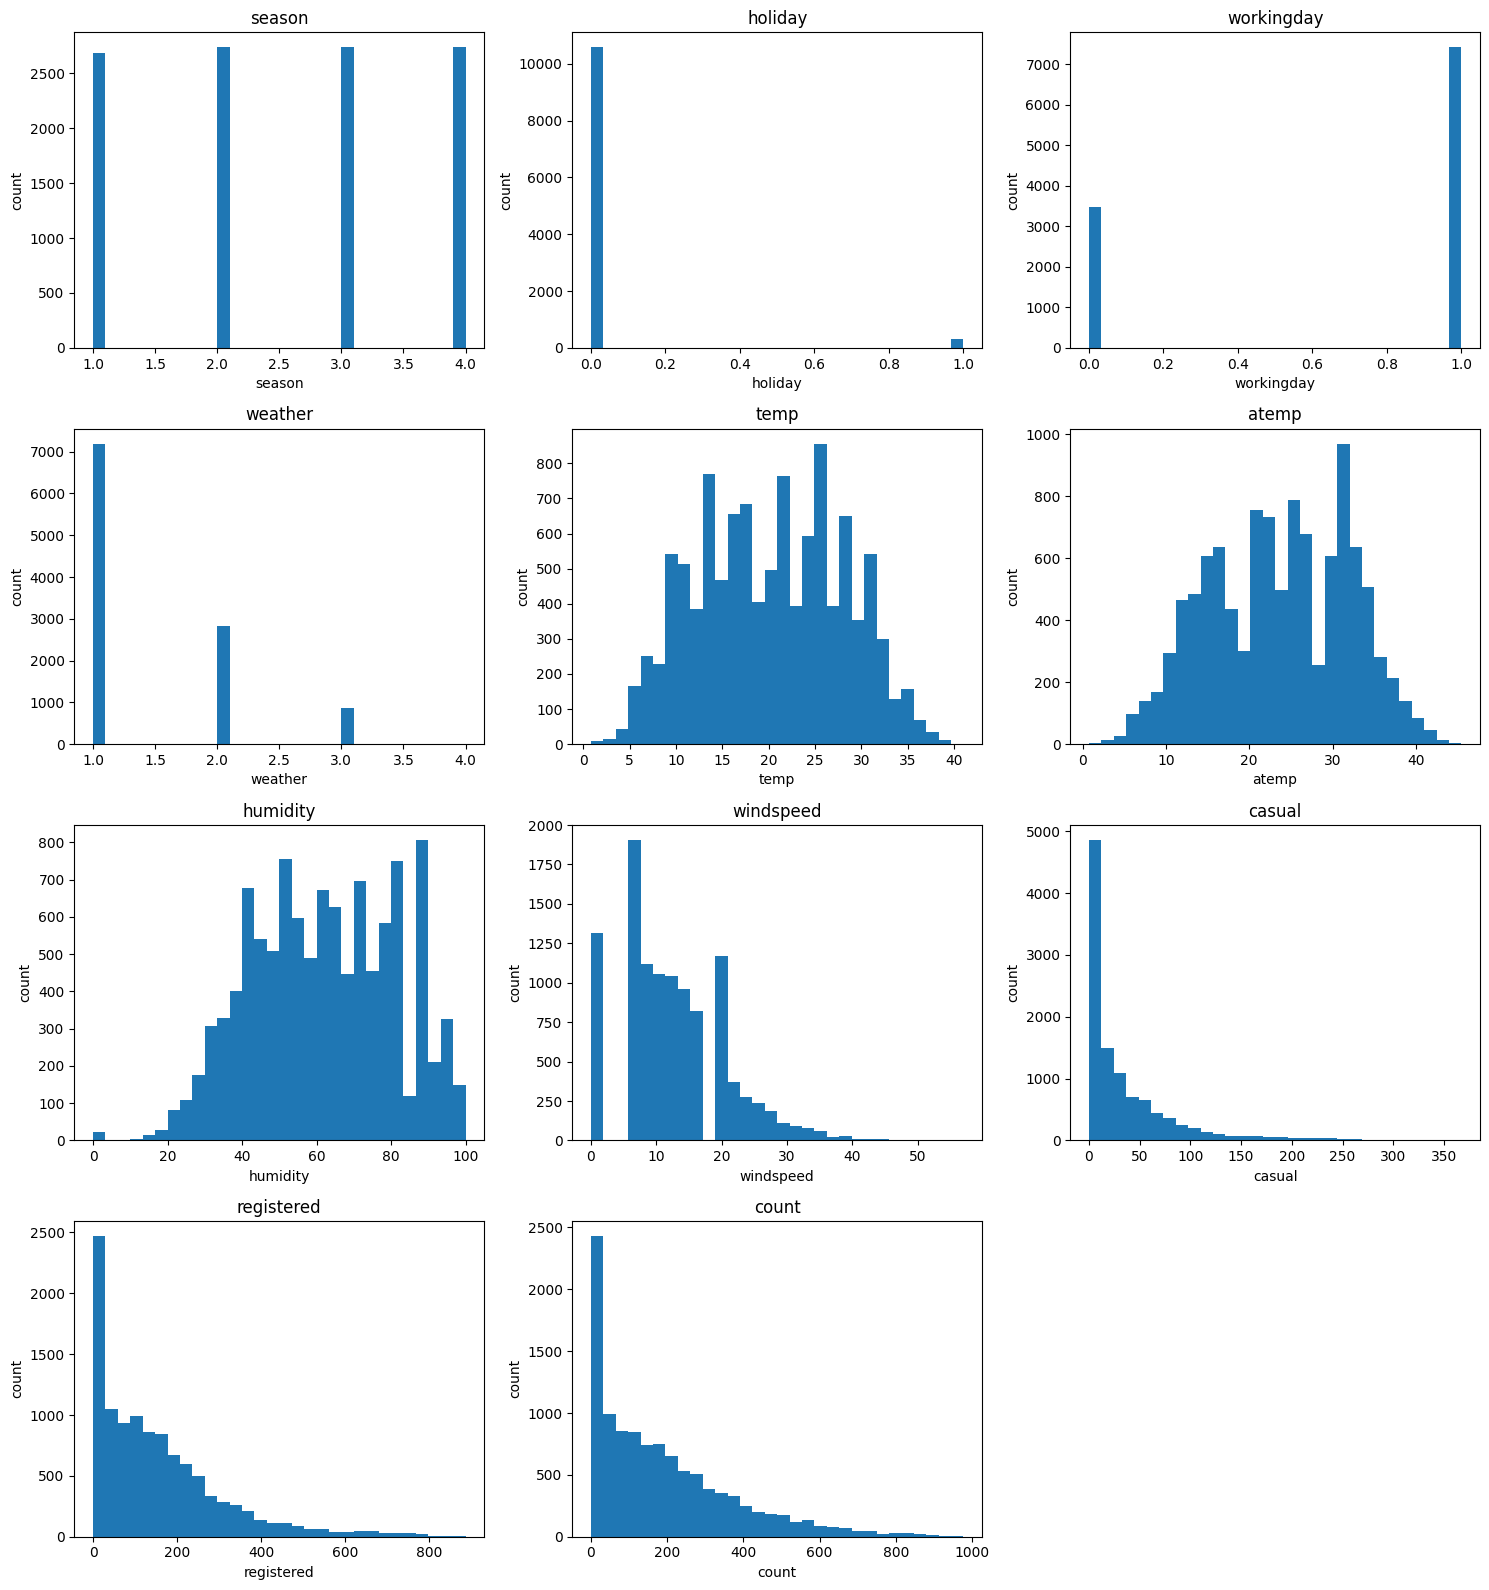

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- season
  - 네 계절 모두 데이터 수가 비교적 비슷하게 분포되어 있다.
  - 그러나 계절의 구분 기준이 복잡하여 나중에 월별 기준으로 컬럼을 재생성 해야할 것 같다.

- holiday
  - 공휴일 데이터가 비공휴일 데이터에 비해 매우 적다.
  - 공휴일 여부에 따른 수요 차이는 확인할 수 있지만, 클래스 비율이 크게 불균형하므로 해석 시 주의가 필요하다.

- workingday
  - 근무일 데이터가 비근무일 데이터보다 약 2배 정도 많다.
  - 자전거 대여 수요는 출퇴근 목적 이용과 관련될 수 있으므로, 이후 시간대별 패턴 분석에서 workingday와 hour를 함께 확인할 필요가 있다.

- weather
  - 맑은 날씨의 데이터가 가장 많고, 날씨가 나빠질수록 데이터 수가 줄어드는 경향이 나타난다.
  - 폭우/폭설에 해당하는 4는 거의 관측되지 않아 해당 범주의 영향은 안정적으로 해석하기 어려울 수 있다.

- temp
  - 기온은 극단적인 값보다는 중간 구간에 주로 분포되어 있다.
  - 분포상 비정상적으로 크게 튀는 값은 뚜렷하게 보이지 않는다.

- atemp
  - 체감온도 역시 중간 구간에 주로 분포되어 있으며, temp와 유사한 형태를 보인다.
  - 실제 온도와 체감온도는 서로 관련성이 높을 가능성이 있으므로, 이후 상관관계 확인이 필요하다.

- humidity
  - 습도는 중간~높은 구간에 많이 분포되어 있다.
  - 다만 0 값이 일부 존재하는데 실제 습도가 0인 상황은 일반적이지 않으므로 추가로 확인할 필요가 있다.

- windspeed
  - 풍속은 낮은 값 구간에 많이 분포되어 있으며 오른쪽으로 긴 꼬리를 보인다.
  - windspeed도 0 값이 비교적 많이 존재하므로 추가 확인이 필요하다.

- casual
  - 비회원 대여량은 0 또는 낮은 값에 많이 몰려 있고, 오른쪽으로 긴 꼬리를 가진다.
  - 일부 큰 값이 존재하지만 이는 특정 시간대나 날씨 조건에서 발생한 실제 수요 증가일 가능성이 있으므로 단순 이상치로 제거하기보다는 이용 패턴으로 해석하는 것이 적절하다.
  - casual은 count를 구성하는 변수이므로 모델 입력 변수로는 사용하지 않는다.

- registered
  - 정기권 회원 대여량 역시 낮은 값에 많이 분포하고, 오른쪽으로 긴 꼬리를 보인다.
  - 큰 값들은 출퇴근 시간대 등 특정 조건에서 발생한 높은 수요일 가능성이 있으므로 제거 대상이라기보다는 수요 특성으로 보는 것이 적절하다.
  - registered 역시 count를 구성하는 변수이므로 모델 입력 변수로는 사용하지 않는다.

- count
  - 전체 대여량은 낮은 값에 많이 몰려 있으며 오른쪽으로 긴 꼬리를 가진다.
  - 이는 자전거 대여 수요 데이터에서 자연스럽게 나타날 수 있는 분포로, 특정 시간대의 높은 수요가 반영된 결과로 볼 수 있다.
  - 모델링 단계에서는 target 분포가 치우쳐 있으므로 log1p(count) 변환을 고려할 수 있다.

**2-3-2. 박스 플롯 시각화**

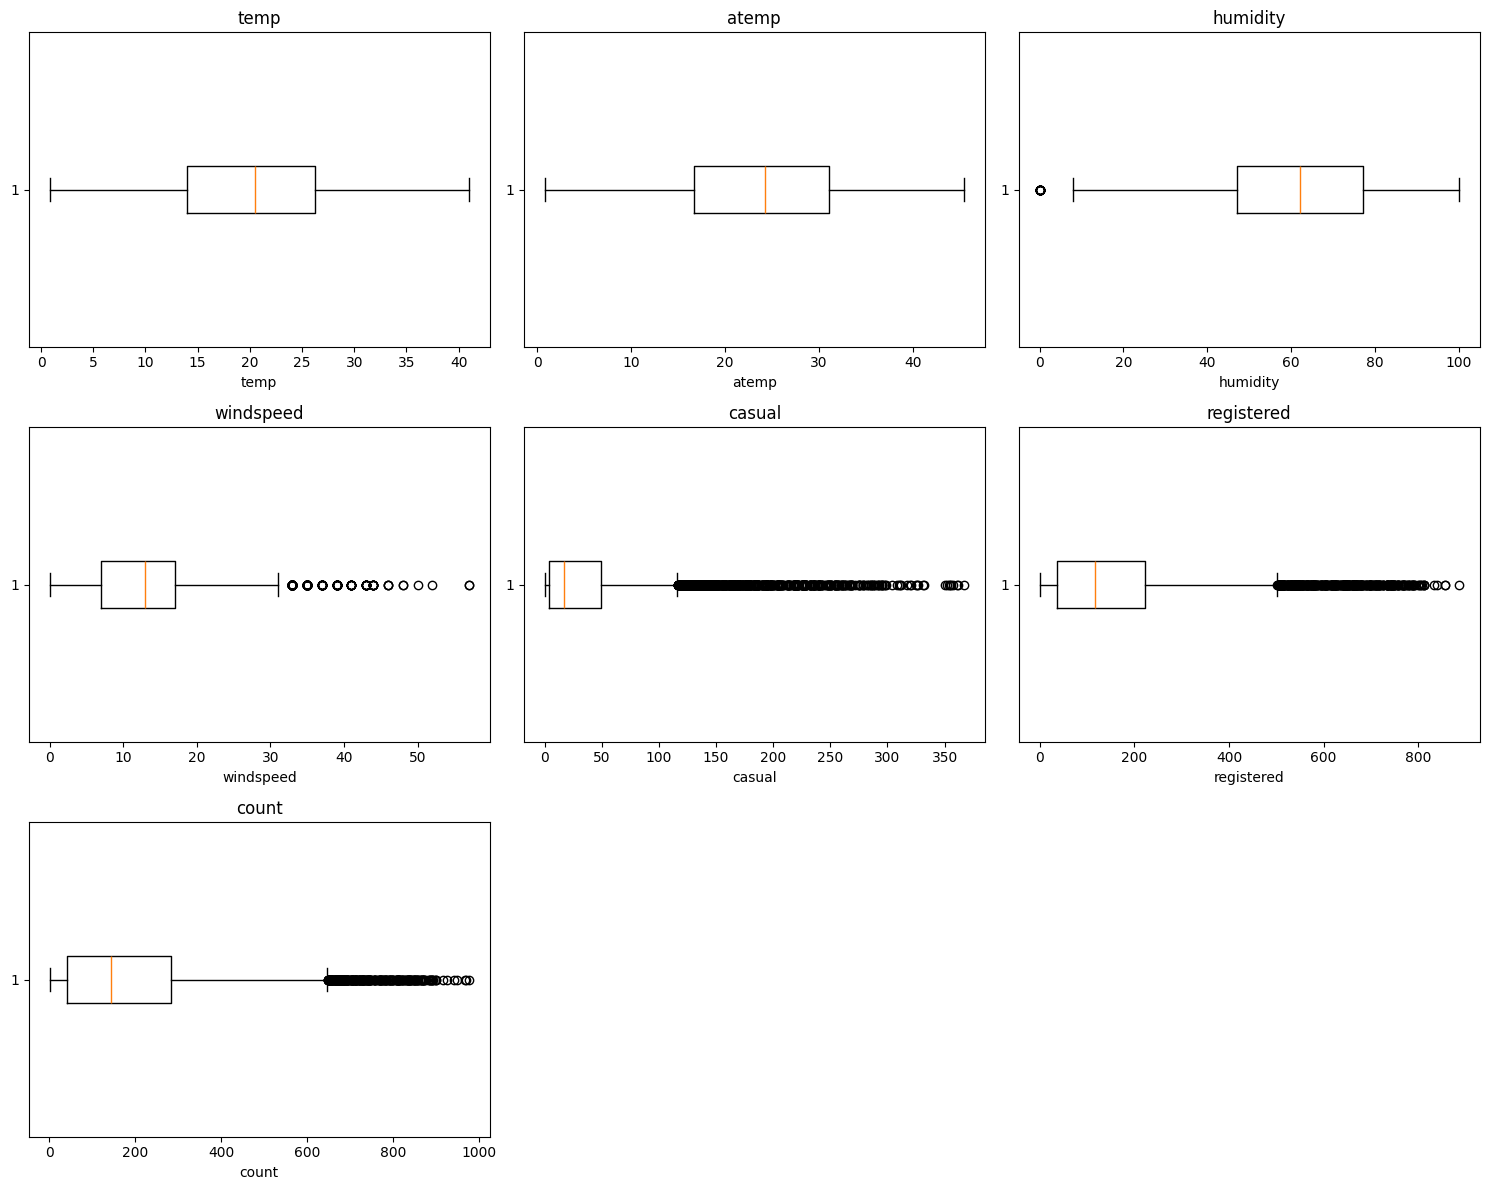

In [ ]:
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

n_cols = 3
n_rows = int(np.ceil(len(continuous_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- temp
  - 박스플롯상 뚜렷한 이상치는 확인되지 않는다.

- atemp
  - 체감온도 역시 뚜렷한 이상치는 확인되지 않는다.

- humidity
  - humidity=0 값이 박스플롯상 이상치로 확인된다.

- windspeed
  - 약 32 이상 구간에서 박스플롯상 이상치가 다수 확인된다.
  - 다만 풍속이 높은 값이라고 해서 반드시 비정상값이라고 단정할 수는 없으므로 실제 가능한 범위인지 확인이 필요하다.

- casual
  - 약 110 이상 값들이 박스플롯상 이상치로 표시된다.
  - 하지만 비회원 대여량은 특정 시간대, 주말, 좋은 날씨 등 조건에 따라 크게 증가할 수 있으므로 단순 제거 대상으로 보기는 어렵다.

- registered
  - 약 500 이상 값들이 박스플롯상 이상치로 표시된다.
  - 정기권 회원 대여량은 출퇴근 시간대에 크게 증가할 수 있으므로, 해당 값들은 실제 이용 패턴에 따른 높은 수요일 가능성이 있다.
  - 따라서 단순 제거보다는 시간대별, 근무일별 패턴 분석에서 함께 확인하는 것이 적절하다.

- count
  - 약 650 이상 값들이 박스플롯상 이상치로 표시된다.
  - 그러나 count는 예측 대상 변수이며, 특정 시간대의 높은 대여 수요를 반영하는 값일 수 있다.
  - 따라서 큰 count 값을 무조건 제거하기보다는, 전체 수요 분포가 오른쪽으로 치우쳐 있다는 점을 고려해 모델링 단계에서 로그 변환을 적용하는 방향이 적절하다.

**2-3-3. 이상치로 판단되는 데이터 제거**

In [ ]:
len(df[df['humidity'] == 0])

22

In [ ]:
df = df[df['humidity'] != 0].copy()
df = df.reset_index(drop=True)
df.shape

(10864, 12)

- NOAA/NCEI의 관측 장비 설명에서는 상대습도를 대기 수분 수용량 대비 백분율로 측정하며 측정 범위가 0%보다 약간 높은 값부터 100%까지라고 설명하고 있다. 이 표현 때문에 실측 데이터에서 정확히 0%가 찍힌 값은 실제 관측값이라기보다는 오류나 비정상값일 가능성이 있다는 점을 확인하였다. (https://www.ncei.noaa.gov/access/crn/measurements.html#rh)

  - 따라서 humidity가 0인 값인 데이터 22건을 모두 제거한다. (제거 후 10,864행)

- 풍속은 0보다 작을 수는 없지만, windspeed=0 자체는 불가능한 값이 아닌 것으로 확인되었다. NWS에서는 바람의 움직임이 감지되지 않는 상태를 Calm으로 정의한다. 또한 ASOS 관측 기준에서는 매우 약한 바람이 calm으로 보고될 수 있으므로, 풍속 0은 실제 무풍 또는 관측/기록 방식에 따른 값일 수 있다고 한다. 따라서 windspeed=0은 humidity=0과 달리 제거 대상으로 보기 어렵다고 판단된다.(https://www.weather.gov/media/asos/aum-toc.pdf?)

  - 따라서 windspeed가 0인 값은 모두 유지한다.

- 미국의 일반 날씨 관측/예보에서는 풍속을 주로 mph(miles per hour)로 표시한다. 항공 관측(METAR)에서는 knots(KT)를 사용한다.
데이터의 windspeed 단위는 미션 명세에 명확히 제시되어 있지 않으므로 단위 자체를 단정하기보다는 분포와 값의 범위를 기준으로 데이터 품질을 확인하였다.

**2-3-4. count 정합성 확인**

In [ ]:
(df['count'] == df['casual'] + df['registered']).value_counts()

,count
True,10864


- 전부 True이므로 target 정합성은 문제가 없다.

## 2-4. 정의되지 않은 값 확인(범주형 컬럼)

각 범주형 변수의 실제 unique 값과 명세상 정의된 값을 비교하여, 정의되지 않은 값이 존재하는지 확인한다.

In [ ]:
valid_values = {
    'season': [1, 2, 3, 4],
    'holiday': [0, 1],
    'workingday': [0, 1],
    'weather': [1, 2, 3, 4]
}

for col, valid in valid_values.items():
    actual_values = sorted(df[col].unique())
    invalid_values = sorted(set(actual_values) - set(valid))

    print(f"[{col}]")
    print("실제 unique 값:", actual_values)
    print("정의되지 않은 값:", invalid_values)

    if len(invalid_values) == 0:
        print("→ 정의되지 않은 값 없음")
    else:
        print("→ 정의되지 않은 값 확인 필요")

    print()

[season]
실제 unique 값: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
정의되지 않은 값: []
→ 정의되지 않은 값 없음

[holiday]
실제 unique 값: [np.int64(0), np.int64(1)]
정의되지 않은 값: []
→ 정의되지 않은 값 없음

[workingday]
실제 unique 값: [np.int64(0), np.int64(1)]
정의되지 않은 값: []
→ 정의되지 않은 값 없음

[weather]
실제 unique 값: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
정의되지 않은 값: []
→ 정의되지 않은 값 없음



- 정의되지 않은 값은 없다.

## 2-5. datetime 전처리 및 기간 확인

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

df.info()
df[['datetime']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10864 entries, 0 to 10863
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10864 non-null  datetime64[ns]
 1   season      10864 non-null  int64         
 2   holiday     10864 non-null  int64         
 3   workingday  10864 non-null  int64         
 4   weather     10864 non-null  int64         
 5   temp        10864 non-null  float64       
 6   atemp       10864 non-null  float64       
 7   humidity    10864 non-null  int64         
 8   windspeed   10864 non-null  float64       
 9   casual      10864 non-null  int64         
 10  registered  10864 non-null  int64         
 11  count       10864 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1018.6 KB


,datetime
0,2011-01-01 00:00:00
1,2011-01-01 01:00:00
2,2011-01-01 02:00:00
3,2011-01-01 03:00:00
4,2011-01-01 04:00:00


In [ ]:
print("시작일:", df['datetime'].min())
print("종료일:", df['datetime'].max())
print("전체 기간:", df['datetime'].max() - df['datetime'].min())

시작일: 2011-01-01 00:00:00
종료일: 2012-12-19 23:00:00
전체 기간: 718 days 23:00:00


- 2011-01-01부터 2012-12-19까지 약 719일 범위이다.

## 2-6. 파생변수 생성

**2-6-1. datetime 기반 파생변수 생성**

In [ ]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek

df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

- 연, 월, 일, 시간, 요일을 추출하고 주말 여부 변수를 생성한다.

In [ ]:
print("일자 최소값:", df['day'].min())
print("일자 최대값:", df['day'].max())
print()

print("day unique:")
print(sorted(df['day'].unique()))

일자 최소값: 1
일자 최대값: 19

day unique:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]


- datetime에서 추출한 day 값을 확인한 결과, 최소 일자는 1일, 최대 일자는 19일로 나타났다.
- day의 unique 값을 확인한 결과, 데이터에는 각 월의 1일~19일 데이터만 포함되어 있었다.
- 따라서 데이터의 전체 기간은 2011년부터 2012년까지로 보이지만, 모든 날짜가 포함된 완전한 월별 데이터는 아니다.

**2-6-2. season 재정의**

In [ ]:
def get_season_by_month(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

df['season_month'] = df['month'].apply(get_season_by_month)

df['season_month'].value_counts().sort_index()

,count
season_month,
fall,2731
spring,2700
summer,2736
winter,2697


- 기존 season 컬럼은 명세상 날짜 기준으로 정의되어 있지만 EDA에서 월별 계절성을 더 직관적으로 해석하기 위해 month 기준의 season_month 변수를 추가로 생성한다.
- 따라서 봄(3\~5월), 여름(6\~8월), 가을(9\~11월), 겨울(12\~2월)로 재분류한다.

**2-6-3. 출퇴근 시간대 파생변수**

In [ ]:
df['rush_hour'] = df['hour'].isin([7, 8, 17, 18, 19]).astype(int)

df['is_commute_time'] = (
    (df['workingday'] == 1) &
    (df['hour'].isin([7, 8, 17, 18, 19]))
).astype(int)

- 출퇴근 시간대 여부와 근무일 출퇴근 시간 여부를 변수로 만든다. (자전거 수요에서 출퇴근 패턴이 중요할 가능성이 높기 때문)

  - rush_hour: 일반적인 출퇴근 시간대 여부
  - is_commute_time: 근무일이면서 출퇴근 시간대인지 여부

**2-6-4. 시간대 구간 파생변수**

In [ ]:
def get_time_period(hour):
    if 0 <= hour <= 5:
        return 'dawn'
    elif 6 <= hour <= 11:
        return 'morning'
    elif 12 <= hour <= 17:
        return 'afternoon'
    else:
        return 'evening'

df['time_period'] = df['hour'].apply(get_time_period)

df['time_period'].value_counts()

,count
time_period,
evening,2730
afternoon,2730
morning,2724
dawn,2680


- 시간대별 수요 패턴을 더 직관적으로 확인하기 위해 hour를 새벽, 오전, 오후, 저녁 구간으로 나눈 time_period 변수를 생성한다.

**2-6-5. 온도 관련 파생변수**

In [ ]:
df['temp_bin'] = pd.cut(
    df['temp'],
    bins=[-1, 10, 20, 30, 50],
    labels=['cold', 'mild', 'warm', 'hot']
)

- 기온 구간별 수요 차이를 확인하기 위해 생성한다.

In [ ]:
print("[temp_bin]")
print(df['temp_bin'].value_counts().sort_index())
print()

[temp_bin]
temp_bin
cold    1259
mild    4027
warm    4334
hot     1244
Name: count, dtype: int64



- mild와 warm 구간의 관측치가 많고 cold와 hot은 상대적으로 적다.

**2-6-6. 풍속 0 여부**

In [ ]:
df['windspeed_zero'] = (df['windspeed'] == 0).astype(int)

- 풍속 0값이 실제 수요 패턴에 영향을 주는지 확인하기 위해 생성한다.

In [ ]:
print("[windspeed_zero]")
print(df['windspeed_zero'].value_counts().sort_index())

[windspeed_zero]
windspeed_zero
0    9551
1    1313
Name: count, dtype: int64


- 풍속 0인 행이 1,313건 존재하므로 별도 확인할 만한 규모로 판단된다.

## 2-7. 최종 전처리 확인

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10864 entries, 0 to 10863
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         10864 non-null  datetime64[ns]
 1   season           10864 non-null  int64         
 2   holiday          10864 non-null  int64         
 3   workingday       10864 non-null  int64         
 4   weather          10864 non-null  int64         
 5   temp             10864 non-null  float64       
 6   atemp            10864 non-null  float64       
 7   humidity         10864 non-null  int64         
 8   windspeed        10864 non-null  float64       
 9   casual           10864 non-null  int64         
 10  registered       10864 non-null  int64         
 11  count            10864 non-null  int64         
 12  year             10864 non-null  int32         
 13  month            10864 non-null  int32         
 14  day              10864 non-null  int32

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,day,hour,dayofweek,is_weekend,season_month,rush_hour,is_commute_time,time_period,temp_bin,windspeed_zero
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,...,1,0,5,1,winter,0,0,dawn,cold,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,...,1,1,5,1,winter,0,0,dawn,cold,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,...,1,2,5,1,winter,0,0,dawn,cold,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,...,1,3,5,1,winter,0,0,dawn,cold,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,...,1,4,5,1,winter,0,0,dawn,cold,1


- 파생변수까지 포함해 총 24개 컬럼이다.

In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
df.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,count,year,month,day,hour,dayofweek,is_weekend,rush_hour,is_commute_time,windspeed_zero
count,10864,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,...,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000
mean,2011-12-27 20:07:05.810014464,2.509665,0.028627,0.680228,1.415409,20.239523,23.663937,62.011782,12.789784,36.090666,...,191.904731,2011.502946,6.528627,9.992544,11.540225,3.013991,0.291145,0.209223,0.142489,0.120858
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,8.000000,0.000000,0.000000,...,1.000000,2011.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2011-07-02 23:45:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,...,43.000000,2011.000000,4.000000,5.000000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2012-01-02 08:30:00,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.998000,17.000000,...,146.000000,2012.000000,7.000000,10.000000,12.000000,3.000000,0.000000,0.000000,0.000000,0.000000
75%,2012-07-01 18:15:00,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,...,284.000000,2012.000000,10.000000,15.000000,18.000000,5.000000,1.000000,0.000000,0.000000,0.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,367.000000,...,977.000000,2012.000000,12.000000,19.000000,23.000000,6.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,1.115241,0.166762,0.466409,0.630784,7.796779,8.480258,19.061721,8.164754,49.987574,...,181.174729,0.500014,3.444208,5.482151,6.916051,2.006614,0.454311,0.406773,0.349567,0.325977


In [ ]:
check_cols = [
    'year', 'month', 'day', 'hour', 'dayofweek',
    'is_weekend', 'season_month', 'rush_hour',
    'is_commute_time', 'time_period', 'temp_bin',
    'windspeed_zero'
]

for col in check_cols:
    print(f"[{col}]")
    print(sorted(df[col].dropna().unique()))
    print()

[year]
[np.int32(2011), np.int32(2012)]

[month]
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

[day]
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]

[hour]
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

[dayofweek]
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]

[is_weekend]
[np.int64(0), np.int64(1)]

[season_month]
['fall', 'spring', 'summer', 

- 의도한 범위와 범주로 잘 생성되었는지 검증한 결과, 이상 없었다.

# 3\. EDA

## 3-1. Target 변수 count 분포 확인

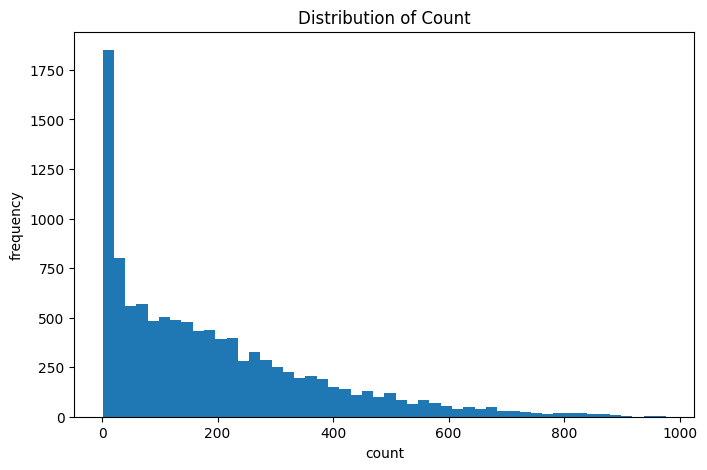

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['count'], bins=50)
plt.title('Distribution of Count')
plt.xlabel('count')
plt.ylabel('frequency')
plt.show()

- 오른쪽 꼬리가 긴 분포라 큰 대여량 일부가 평균을 끌어올리는 구조이다.

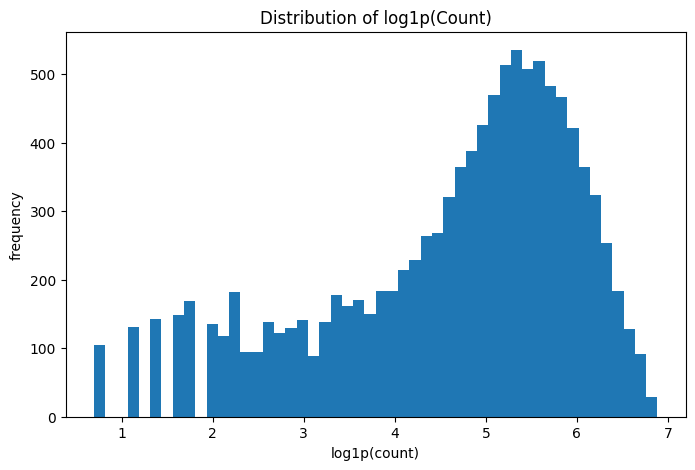

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df['count']), bins=50)
plt.title('Distribution of log1p(Count)')
plt.xlabel('log1p(count)')
plt.ylabel('frequency')
plt.show()

- 원본보다 치우침이 완화되어 회귀 모델링에 더 적합해졌다.

In [ ]:
df['count'].describe()

,count
count,10864.000000
mean,191.904731
std,181.174729
min,1.000000
25%,43.000000
50%,146.000000
75%,284.000000
max,977.000000


- 평균은 약 192, 중앙값은 146으로 평균이 더 높아 오른쪽 치우침이 있음을 보여준다.

In [ ]:
print("count skew:", df['count'].skew())
print("log1p(count) skew:", np.log1p(df['count']).skew())

count skew: 1.240070181469599
log1p(count) skew: -0.8551269323306843


- 원본 count와 log 변환 count의 왜도 비교 결과, log 변환 후 왜도가 크게 줄어 target 로그 변환이 타당하다고 판단된다.

## 3-2. casual / registered / count 분포 비교

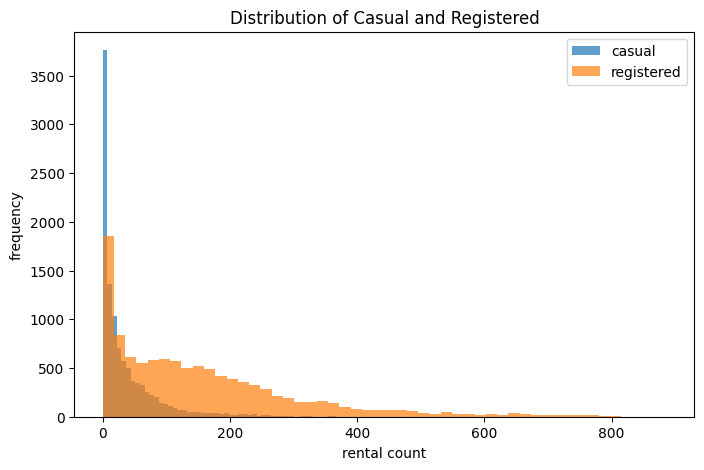

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['casual'], bins=50, alpha=0.7, label='casual')
plt.hist(df['registered'], bins=50, alpha=0.7, label='registered')
plt.title('Distribution of Casual and Registered')
plt.xlabel('rental count')
plt.ylabel('frequency')
plt.legend()
plt.show()

- registered가 전체 count에 더 큰 비중을 차지한다.

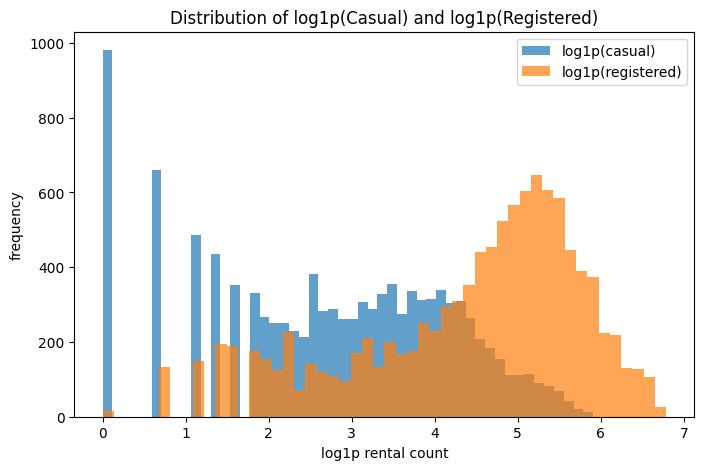

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df['casual']), bins=50, alpha=0.7, label='log1p(casual)')
plt.hist(np.log1p(df['registered']), bins=50, alpha=0.7, label='log1p(registered)')
plt.title('Distribution of log1p(Casual) and log1p(Registered)')
plt.xlabel('log1p rental count')
plt.ylabel('frequency')
plt.legend()
plt.show()

- casual/registered에도 log 변환을 적용해 분포를 비교한 결과, 두 변수 모두 원본보다 분포가 완화되어 비교가 쉬워질 것으로 판단된다.

In [ ]:
df[['casual', 'registered', 'count']].describe()

,casual,registered,count
count,10864.000000,10864.000000,10864.000000
mean,36.090666,155.814065,191.904731
std,49.987574,151.075130,181.174729
min,0.000000,0.000000,1.000000
25%,4.000000,36.000000,43.000000
50%,17.000000,119.000000,146.000000
75%,49.000000,223.000000,284.000000
max,367.000000,886.000000,977.000000


- registered 평균이 casual보다 훨씬 높아 전체 대여량 변동의 핵심 축인 걸로 보인다.

## 3-3. 연도별 대여량 확인

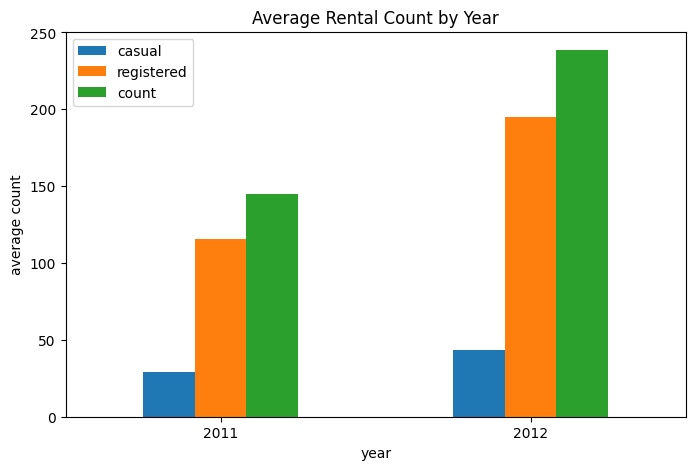

In [ ]:
year_count = df.groupby('year')[['casual', 'registered', 'count']].mean()
year_count
year_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Year')
plt.xlabel('year')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 2012년 평균 대여량이 2011년보다 높아 서비스 이용 규모가 증가한 흐름으로 해석할 수 있다.

## 3-4. 월별 대여량 확인

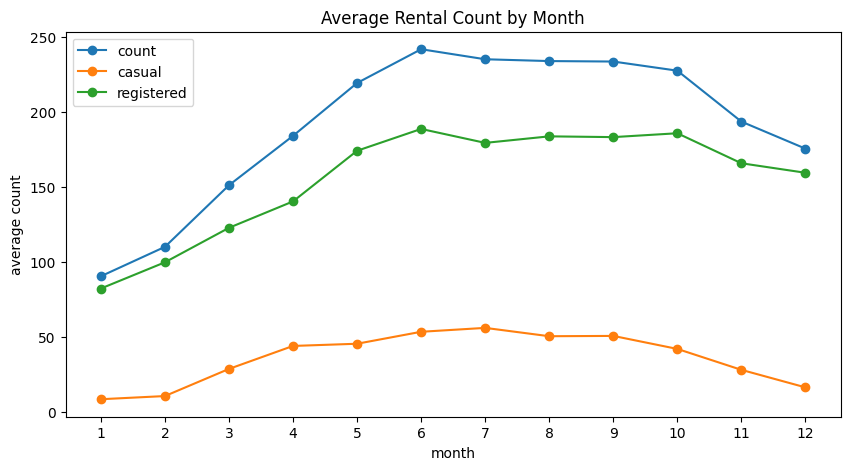

In [ ]:
month_count = df.groupby('month')[['casual', 'registered', 'count']].mean()
month_count

plt.figure(figsize=(10, 5))
plt.plot(month_count.index, month_count['count'], marker='o', label='count')
plt.plot(month_count.index, month_count['casual'], marker='o', label='casual')
plt.plot(month_count.index, month_count['registered'], marker='o', label='registered')
plt.title('Average Rental Count by Month')
plt.xlabel('month')
plt.ylabel('average count')
plt.xticks(range(1, 13))
plt.legend()
plt.show()

- 계절성이 뚜렷하며 추운 달보다 따뜻한 달의 수요가 높게 나타난다.

## 3-5. 계절별 대여량 확인

**3-5-1. 기존 season**

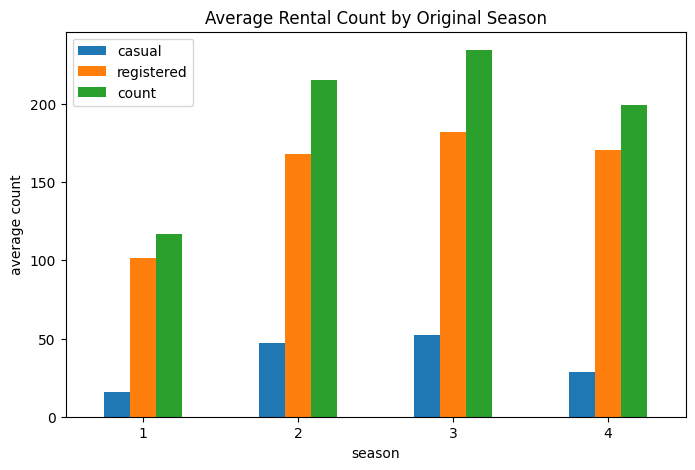

In [ ]:
season_count = df.groupby('season')[['casual', 'registered', 'count']].mean()
season_count
season_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Original Season')
plt.xlabel('season')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 기존 season 값 기준: 계절별 수요 차이가 존재하며 낮은 계절과 높은 계절이 구분된다.

**3-5-2. month 기준 season_month**

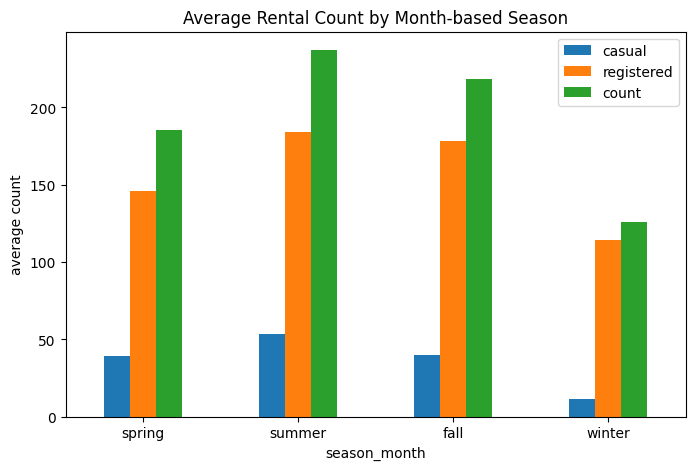

In [ ]:
season_month_count = df.groupby('season_month')[['casual', 'registered', 'count']].mean()
season_month_count
season_order = ['spring', 'summer', 'fall', 'winter']
season_month_count = df.groupby('season_month')[['casual', 'registered', 'count']].mean()
season_month_count = season_month_count.loc[season_order]
season_month_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Month-based Season')
plt.xlabel('season_month')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 재정의 season 기준: 봄/여름/가을/겨울 흐름을 더 직관적으로 해석할 수 있다.

## 3-6. 시간대별 대여량 확인

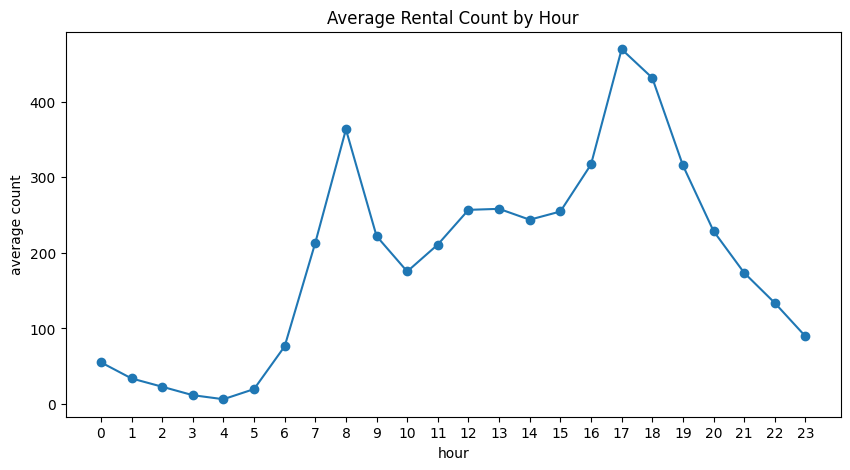

In [ ]:
hour_count = df.groupby('hour')['count'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(hour_count['hour'], hour_count['count'], marker='o')
plt.title('Average Rental Count by Hour')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.show()

- 출근/퇴근 시간대에 수요가 커지는 패턴이 나타난다.

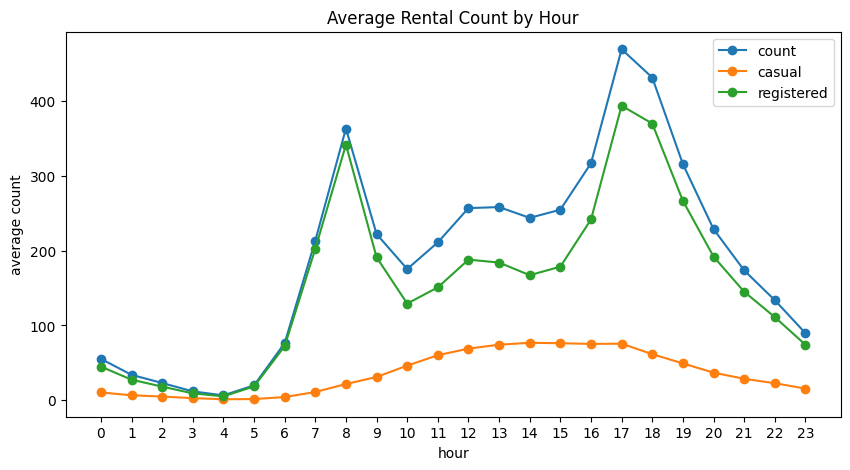

In [ ]:
hour_count = df.groupby('hour')[['casual', 'registered', 'count']].mean()
hour_count

plt.figure(figsize=(10, 5))
plt.plot(hour_count.index, hour_count['count'], marker='o', label='count')
plt.plot(hour_count.index, hour_count['casual'], marker='o', label='casual')
plt.plot(hour_count.index, hour_count['registered'], marker='o', label='registered')
plt.title('Average Rental Count by Hour')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

- 피크는 주로 정기권 회원인 registered의 대여량 증가와 같은 흐름을 보였다.
- 반면 비회원 이용자인 casual은 출퇴근 시간대보다는 낮 시간대에 완만하게 증가하는 패턴을 보였다.

## 3-7. 근무일 여부별 시간대 대여량 확인

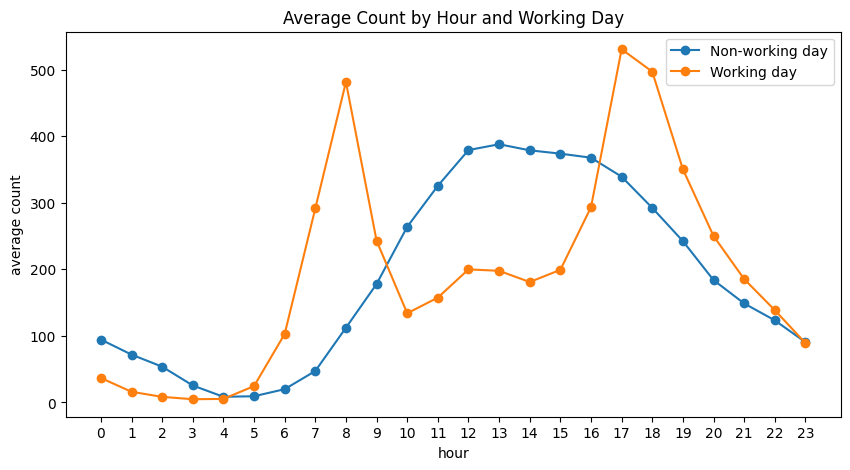

In [ ]:
hour_workingday = df.groupby(['hour', 'workingday'])['count'].mean().unstack()
hour_workingday

plt.figure(figsize=(10, 5))
plt.plot(hour_workingday.index, hour_workingday[0], marker='o', label='Non-working day')
plt.plot(hour_workingday.index, hour_workingday[1], marker='o', label='Working day')
plt.title('Average Count by Hour and Working Day')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

- 근무일에는 출퇴근 피크가 뚜렷하고 비근무일은 낮 시간대 수요가 상대적으로 크다.

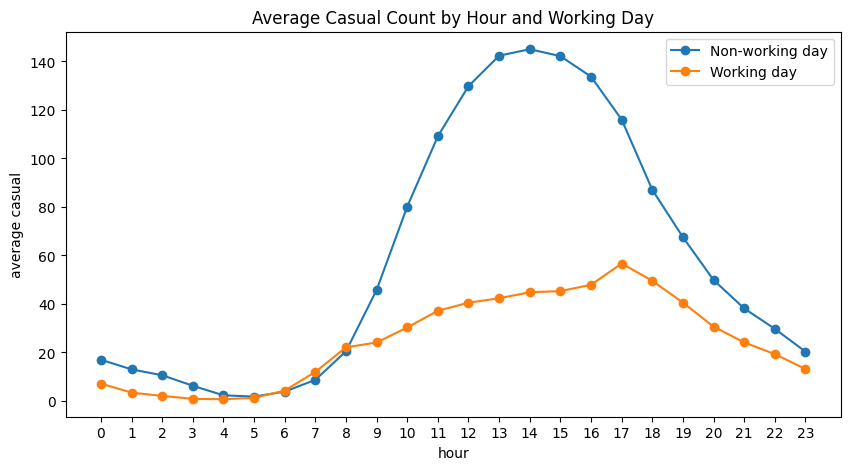

In [ ]:
hour_workingday_user = df.groupby(['hour', 'workingday'])[['casual', 'registered']].mean()
hour_workingday_user

hour_workingday_casual = df.groupby(['hour', 'workingday'])['casual'].mean().unstack()
plt.figure(figsize=(10, 5))
plt.plot(hour_workingday_casual.index, hour_workingday_casual[0], marker='o', label='Non-working day')
plt.plot(hour_workingday_casual.index, hour_workingday_casual[1], marker='o', label='Working day')
plt.title('Average Casual Count by Hour and Working Day')
plt.xlabel('hour')
plt.ylabel('average casual')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

- 비회원은 출퇴근보다는 비근무일 낮 시간대 이용 성격이 더 강하다.

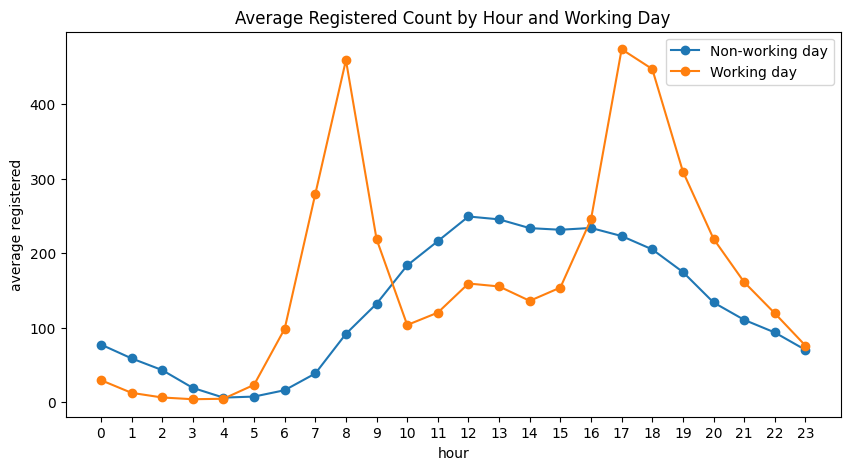

In [ ]:
hour_workingday_registered = df.groupby(['hour', 'workingday'])['registered'].mean().unstack()

plt.figure(figsize=(10, 5))
plt.plot(hour_workingday_registered.index, hour_workingday_registered[0], marker='o', label='Non-working day')
plt.plot(hour_workingday_registered.index, hour_workingday_registered[1], marker='o', label='Working day')
plt.title('Average Registered Count by Hour and Working Day')
plt.xlabel('hour')
plt.ylabel('average registered')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

- 회원은 근무일 출퇴근 시간대 수요가 뚜렷해 통근 목적 이용 가능성이 크다.

## 3-8. 요일별 대여량 확인

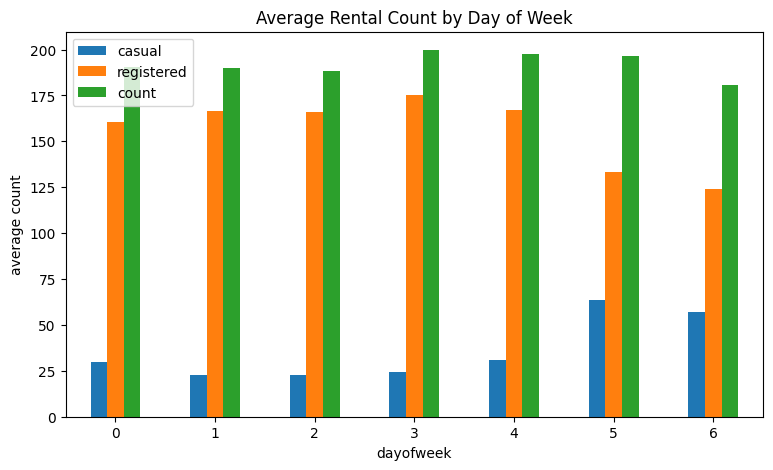

In [ ]:
dayofweek_count = df.groupby('dayofweek')[['casual', 'registered', 'count']].mean()
dayofweek_count

dayofweek_count.plot(kind='bar', figsize=(9, 5))
plt.title('Average Rental Count by Day of Week')
plt.xlabel('dayofweek')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 단순 요일 평균만으로는 큰 차이가 제한적인 것으로 보인다.

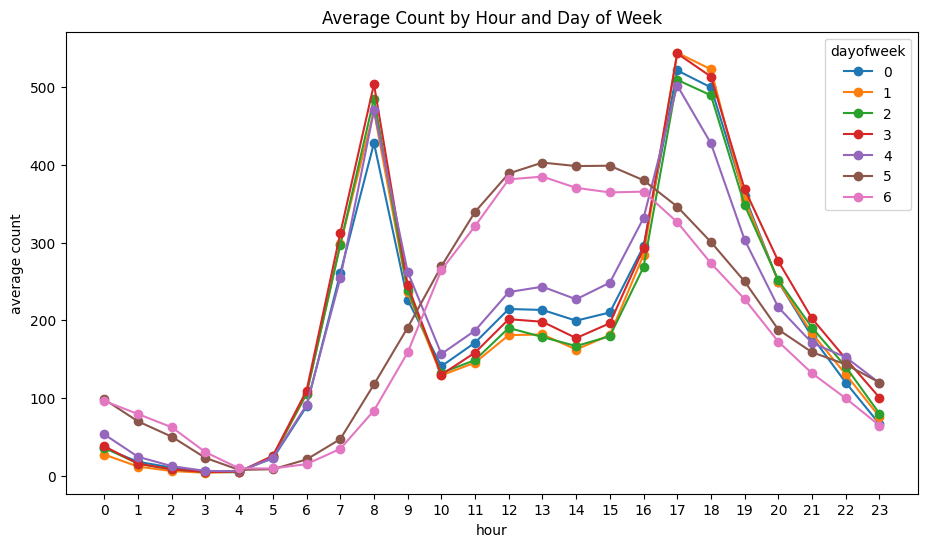

In [ ]:
dayofweek_hour = df.groupby(['hour', 'dayofweek'])['count'].mean().unstack()
plt.figure(figsize=(11, 6))

for col in dayofweek_hour.columns:
    plt.plot(dayofweek_hour.index, dayofweek_hour[col], marker='o', label=col)

plt.title('Average Count by Hour and Day of Week')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend(title='dayofweek')
plt.show()

- 요일별 차이보다 시간대 피크 패턴이 더 강하게 드러난다.

## 3-9. 주말 여부별 대여량 확인

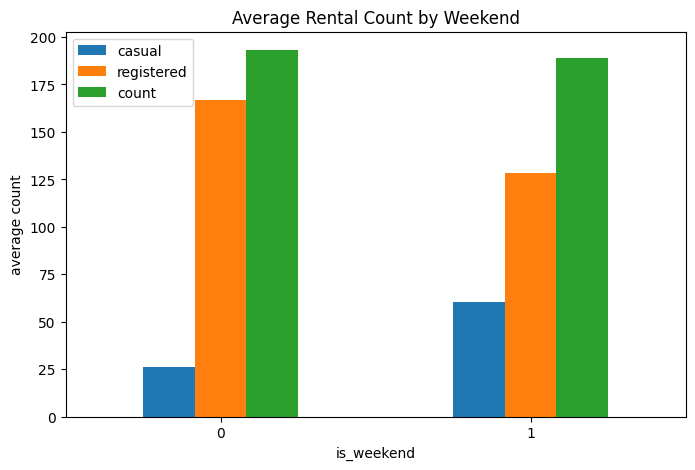

In [ ]:
weekend_count = df.groupby('is_weekend')[['casual', 'registered', 'count']].mean()
weekend_count
weekend_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Weekend')
plt.xlabel('is_weekend')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 전체 평균만 보면 주말/평일 차이가 크지 않을 수 있는 것으로 보인다.

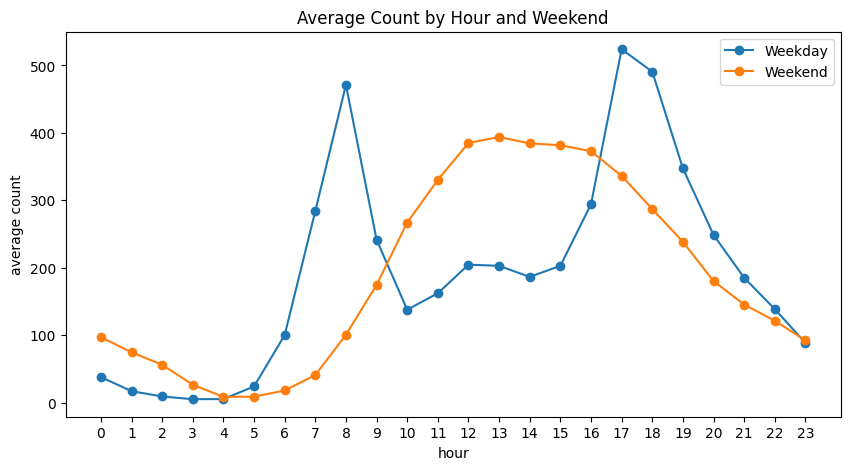

In [ ]:
hour_weekend = df.groupby(['hour', 'is_weekend'])['count'].mean().unstack()
plt.figure(figsize=(10, 5))
plt.plot(hour_weekend.index, hour_weekend[0], marker='o', label='Weekday')
plt.plot(hour_weekend.index, hour_weekend[1], marker='o', label='Weekend')
plt.title('Average Count by Hour and Weekend')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

- 평일은 출퇴근 피크, 주말은 낮 시간대 중심이라는 차이가 명확하게 보인다.

## 3-10. 공휴일 여부별 대여량 확인

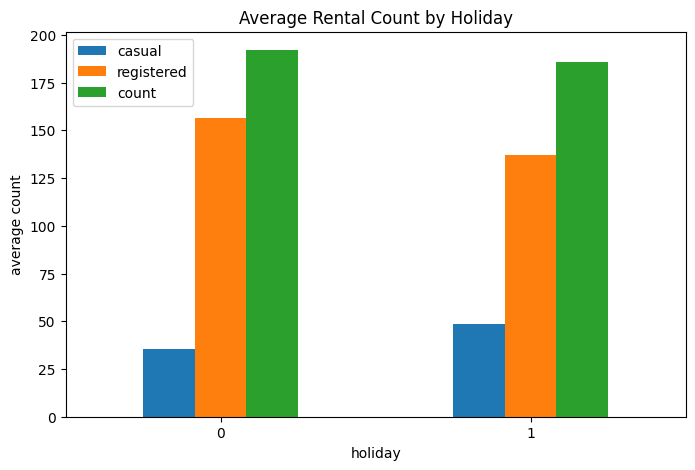

,count
holiday,
0,10553
1,311


In [ ]:
holiday_count = df.groupby('holiday')[['casual', 'registered', 'count']].mean()
holiday_count
holiday_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Holiday')
plt.xlabel('holiday')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()
df['holiday'].value_counts().sort_index()

- 공휴일 데이터가 311건으로 적어 해석 시 표본 불균형에 주의해야 한다.

## 3-11. 날씨별 대여량 확인


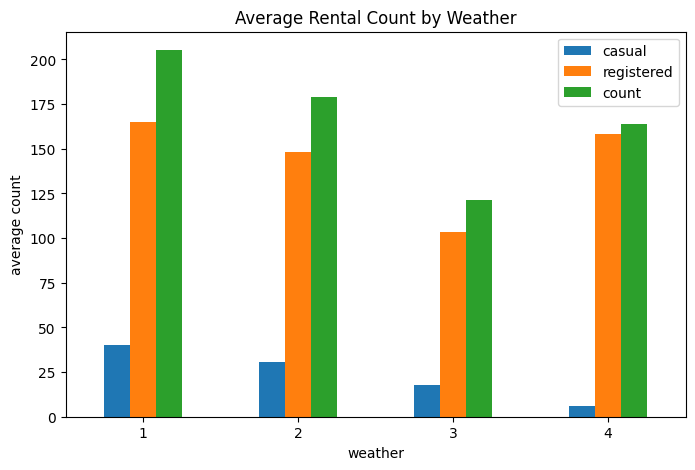

In [ ]:
weather_count = df.groupby('weather')[['casual', 'registered', 'count']].mean()
weather_count
weather_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Weather')
plt.xlabel('weather')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 날씨가 나쁠수록 수요가 낮아지는 경향이 있으며 weather 4는 관측치가 매우 적다는 부분도 고려해야 한다. (2-3의 히스토그램)

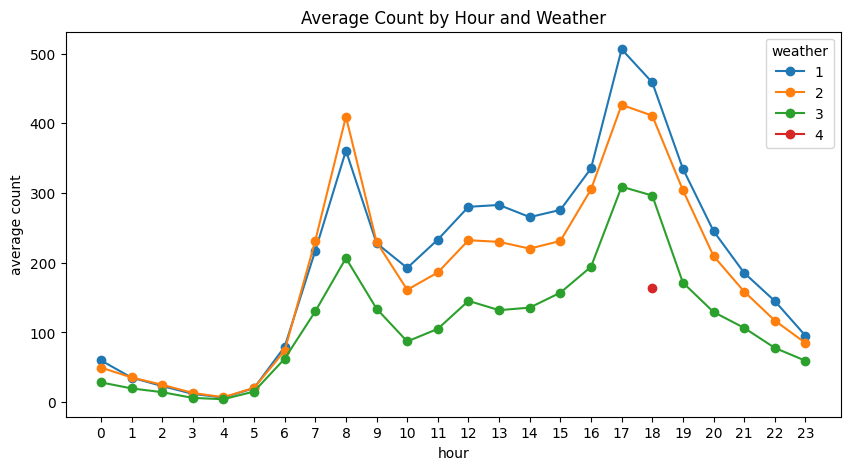

In [ ]:
df['weather'].value_counts().sort_index()
weather_hour = df.groupby(['hour', 'weather'])['count'].mean().unstack()
plt.figure(figsize=(10, 5))
for col in weather_hour.columns:
    plt.plot(weather_hour.index, weather_hour[col], marker='o', label=col)
plt.title('Average Count by Hour and Weather')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend(title='weather')
plt.show()

- 날씨가 좋을 때 전반적인 수요가 높고 악천후 범주는 표본이 적어 전체적인 해석이 어렵다.

## 3-12. 기온과 대여량 관계 확인

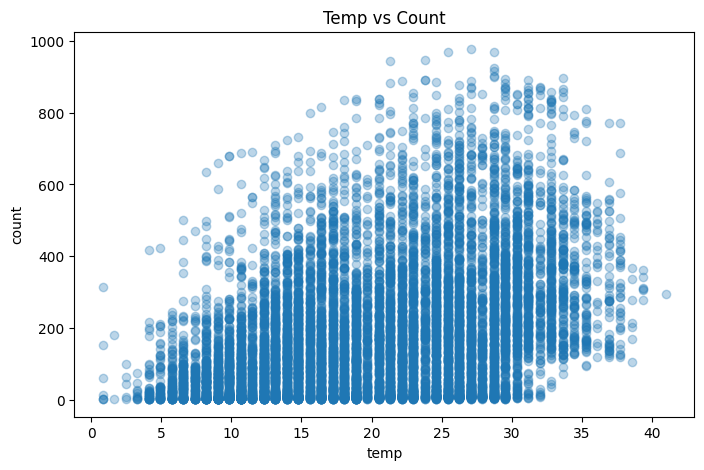

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['temp'], df['count'], alpha=0.3)
plt.title('Temp vs Count')
plt.xlabel('temp')
plt.ylabel('count')
plt.show()

- 기온이 올라갈수록 대여량이 증가하는 경향이 있지만 완전한 직선 관계는 아니다.

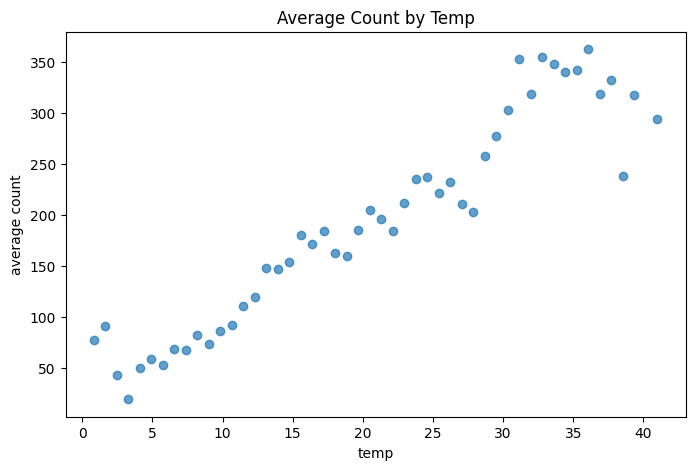

In [ ]:
temp_count = df.groupby('temp')['count'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.scatter(temp_count['temp'], temp_count['count'], alpha=0.7)
plt.title('Average Count by Temp')
plt.xlabel('temp')
plt.ylabel('average count')
plt.show()

- 개별값보다 평균 패턴을 보면 기온 상승에 따른 수요 증가가 더 명확하게 보인다.

## 3-13. 체감온도와 대여량 관계 확인

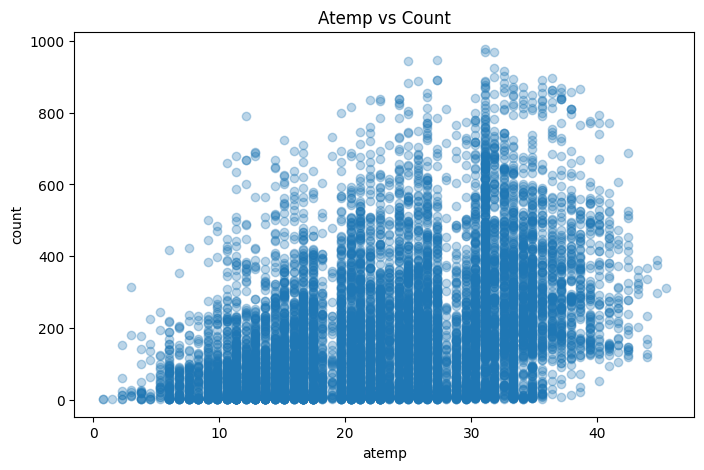

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['atemp'], df['count'], alpha=0.3)
plt.title('Atemp vs Count')
plt.xlabel('atemp')
plt.ylabel('count')
plt.show()

- 실제 기온과 유사하게 체감온도가 높을수록 수요가 증가하는 경향이 있다.

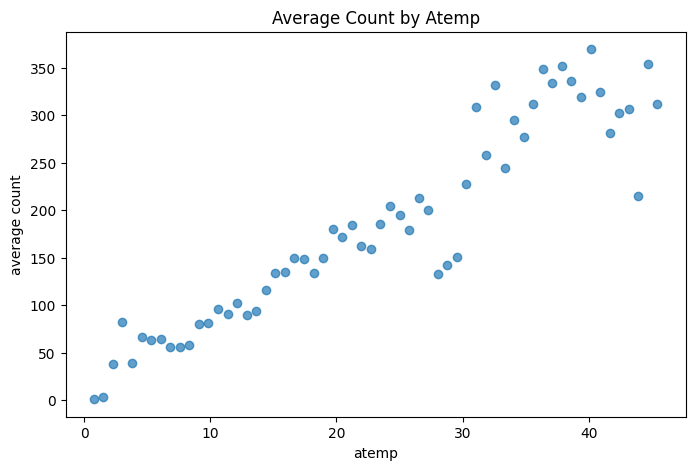

In [ ]:
atemp_count = df.groupby('atemp')['count'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.scatter(atemp_count['atemp'], atemp_count['count'], alpha=0.7)
plt.title('Average Count by Atemp')
plt.xlabel('atemp')
plt.ylabel('average count')
plt.show()

- 평균 패턴에서도 체감온도와 수요의 양의 관계가 명확하게 나타난다.

## 3-14. 기온 구간별 대여량 확인

/tmp/ipykernel_5947/4082371348.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_count = df.groupby('temp_bin')[['casual', 'registered', 'count']].mean()


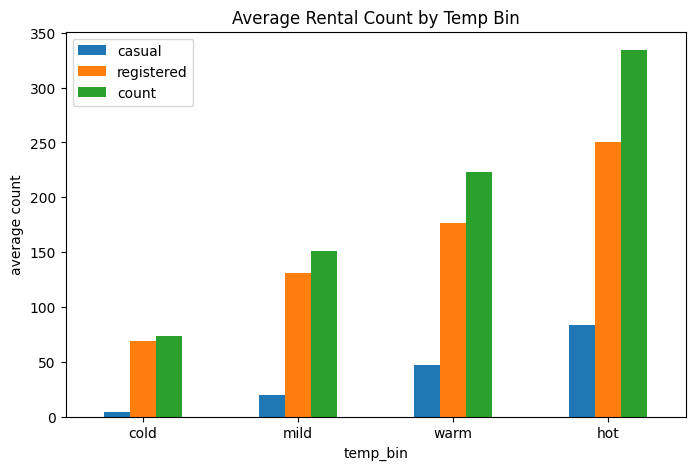

In [ ]:
temp_bin_count = df.groupby('temp_bin')[['casual', 'registered', 'count']].mean()
temp_bin_count
temp_bin_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Temp Bin')
plt.xlabel('temp_bin')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 너무 낮은 기온보다 온화하거나 따뜻한 구간에서 수요가 높게 나타난다.

## 3-15. 습도와 대여량 관계 확인

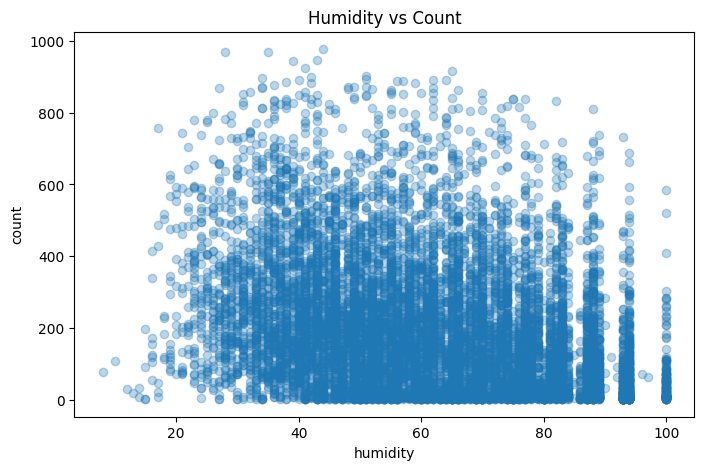

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['humidity'], df['count'], alpha=0.3)
plt.title('Humidity vs Count')
plt.xlabel('humidity')
plt.ylabel('count')
plt.show()

- 습도가 높을수록 수요가 낮아지는 경향이 있다.

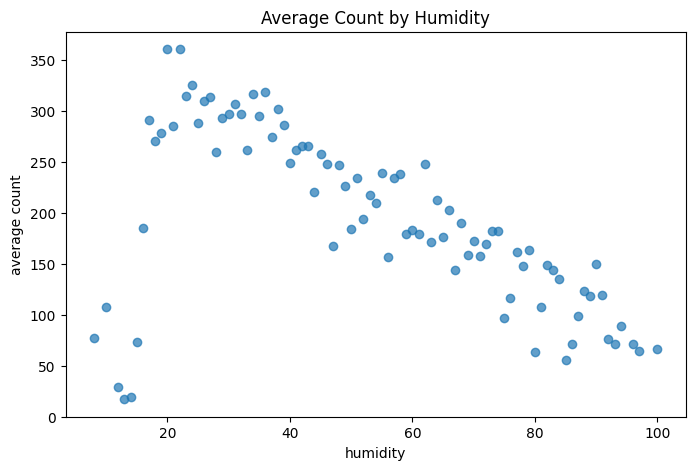

In [ ]:
humidity_count = df.groupby('humidity')['count'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.scatter(humidity_count['humidity'], humidity_count['count'], alpha=0.7)
plt.title('Average Count by Humidity')
plt.xlabel('humidity')
plt.ylabel('average count')
plt.show()

- 개별 산점도보다 평균 기준에서 습도 증가에 따른 감소 경향을 확인하기 쉬운걸로 보인다.

## 3-16. 습도 구간 생성 후 대여량 확인

/tmp/ipykernel_5947/1476894710.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humidity_bin_count = df.groupby('humidity_bin')[['casual', 'registered', 'count']].mean()


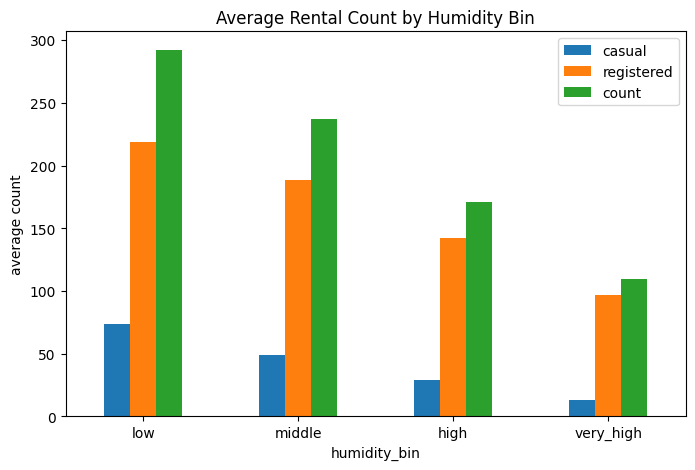

In [ ]:
df['humidity_bin'] = pd.cut(
    df['humidity'],
    bins=[0, 30, 60, 80, 100],
    labels=['low', 'middle', 'high', 'very_high'],
    include_lowest=True
)

df['humidity_bin'].value_counts().sort_index()
humidity_bin_count = df.groupby('humidity_bin')[['casual', 'registered', 'count']].mean()
humidity_bin_count

humidity_bin_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Humidity Bin')
plt.xlabel('humidity_bin')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 습도가 높은 구간일수록 대여량이 낮아지는 흐름을 확인할 수 있다.

## 3-17. 풍속과 대여량 관계 확인

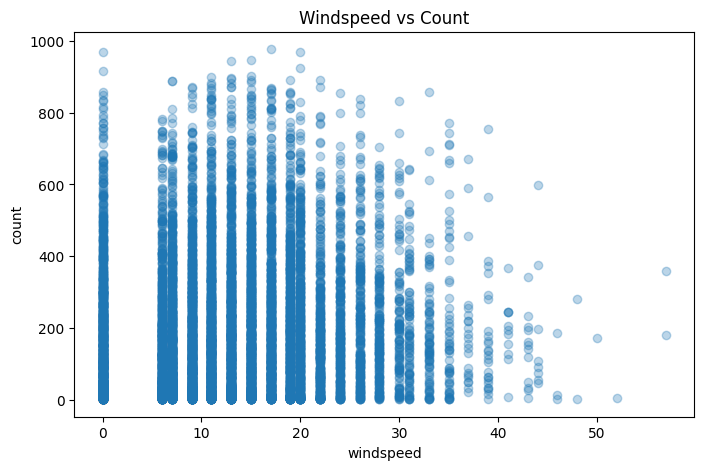

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['windspeed'], df['count'], alpha=0.3)
plt.title('Windspeed vs Count')
plt.xlabel('windspeed')
plt.ylabel('count')
plt.show()

- 풍속과 수요의 관계는 기온/습도보다는 약해 보인다.

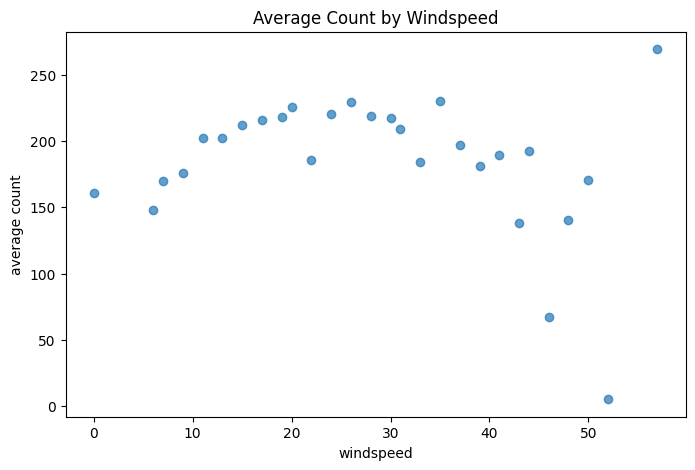

In [ ]:
windspeed_count = df.groupby('windspeed')['count'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.scatter(windspeed_count['windspeed'], windspeed_count['count'], alpha=0.7)
plt.title('Average Count by Windspeed')
plt.xlabel('windspeed')
plt.ylabel('average count')
plt.show()

- 풍속 단독 효과는 뚜렷하지 않아 모델에서 중요도가 낮을 가능성이 있다.

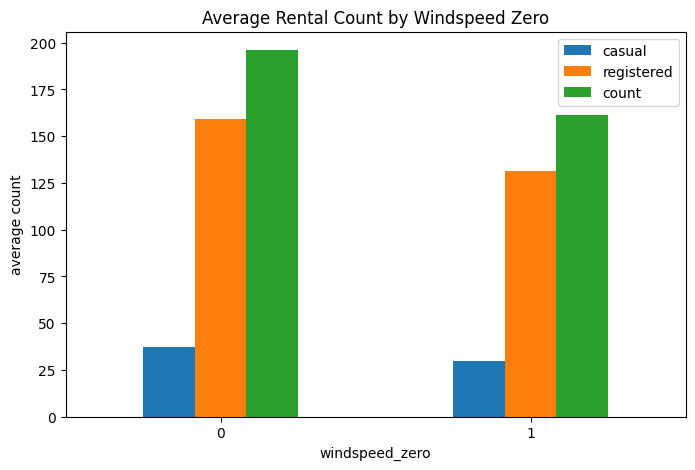

In [ ]:
windspeed_zero_count = df.groupby('windspeed_zero')[['casual', 'registered', 'count']].mean()
windspeed_zero_count

windspeed_zero_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Windspeed Zero')
plt.xlabel('windspeed_zero')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- windspeed_zero가 수요 차이를 일부 보일 수 있으나 이는 보조적으로 보는 것이 적절하다 판단된다.

## 3-18. 출퇴근 시간 파생변수 확인

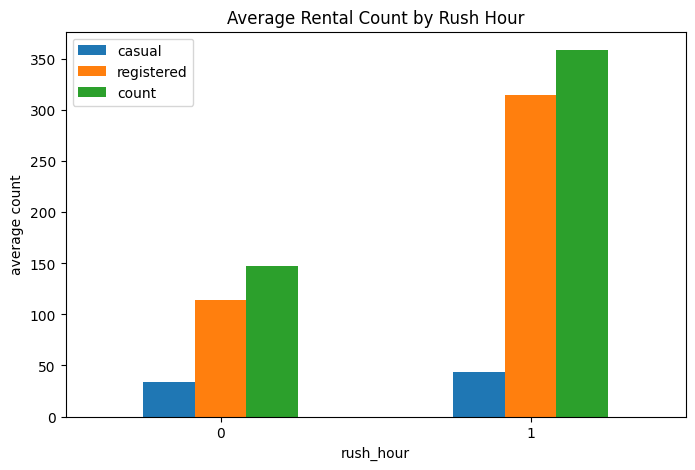

In [ ]:
rush_hour_count = df.groupby('rush_hour')[['casual', 'registered', 'count']].mean()
rush_hour_count

rush_hour_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Rush Hour')
plt.xlabel('rush_hour')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 출퇴근 시간대의 평균 수요가 높아 rush_hour 변수가 유의미한 후보로 보인다.

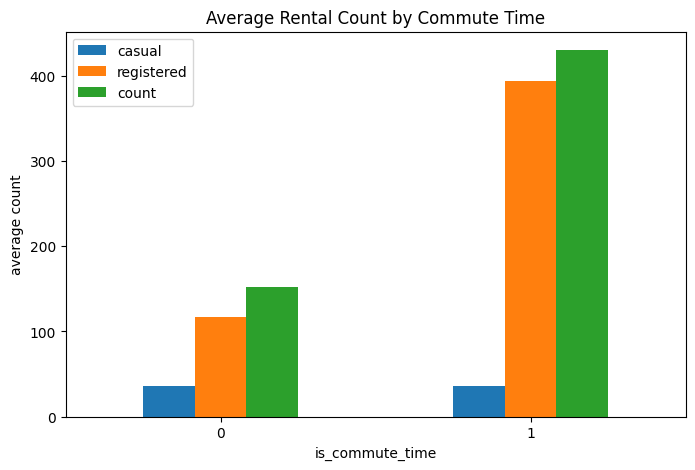

In [ ]:
commute_count = df.groupby('is_commute_time')[['casual', 'registered', 'count']].mean()
commute_count

commute_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Commute Time')
plt.xlabel('is_commute_time')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 실제 통근 수요를 더 직접적으로 반영하는 변수로 보인다.

## 3-19. 시간대 구간별 대여량 확인

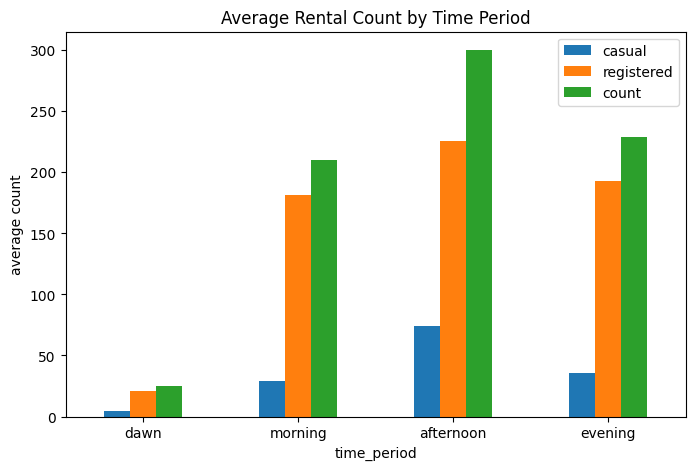

In [ ]:
time_period_count = df.groupby('time_period')[['casual', 'registered', 'count']].mean()
time_period_count

time_period_order = ['dawn', 'morning', 'afternoon', 'evening']
time_period_count = df.groupby('time_period')[['casual', 'registered', 'count']].mean()
time_period_count = time_period_count.loc[time_period_order]
time_period_count.plot(kind='bar', figsize=(8, 5))
plt.title('Average Rental Count by Time Period')
plt.xlabel('time_period')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.show()

- 새벽 수요는 낮고, 오후/저녁 수요가 상대적으로 높게 나타난다.

## 3-20. 월 X 시간대 패턴 확인

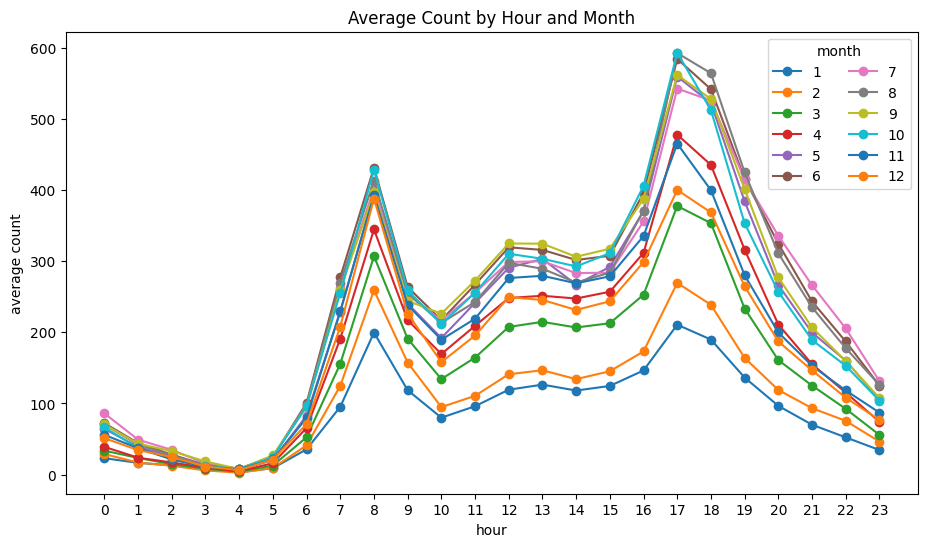

In [ ]:
month_hour = df.groupby(['hour', 'month'])['count'].mean().unstack()
plt.figure(figsize=(11, 6))
for col in month_hour.columns:
    plt.plot(month_hour.index, month_hour[col], marker='o', label=col)
plt.title('Average Count by Hour and Month')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend(title='month', ncol=2)
plt.show()

- 따뜻한 달의 출퇴근/낮 시간 수요가 더 높게 나타난다.

## 3-21. 계절 X 시간대 패턴 확인

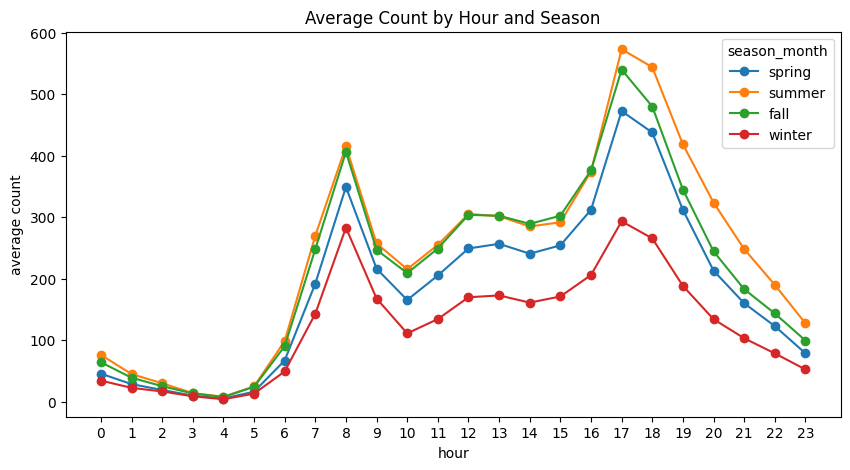

In [ ]:
season_hour = df.groupby(['hour', 'season_month'])['count'].mean().unstack()
season_hour = season_hour[season_order]
plt.figure(figsize=(10, 5))
for col in season_hour.columns:
    plt.plot(season_hour.index, season_hour[col], marker='o', label=col)
plt.title('Average Count by Hour and Season')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.legend(title='season_month')
plt.show()

- 계절별 차이와 출퇴근 피크가 함께 반영되어 수요 패턴을 더 잘 설명하는 걸로 보인다.

## 3-22. casual / registered 비중 확인

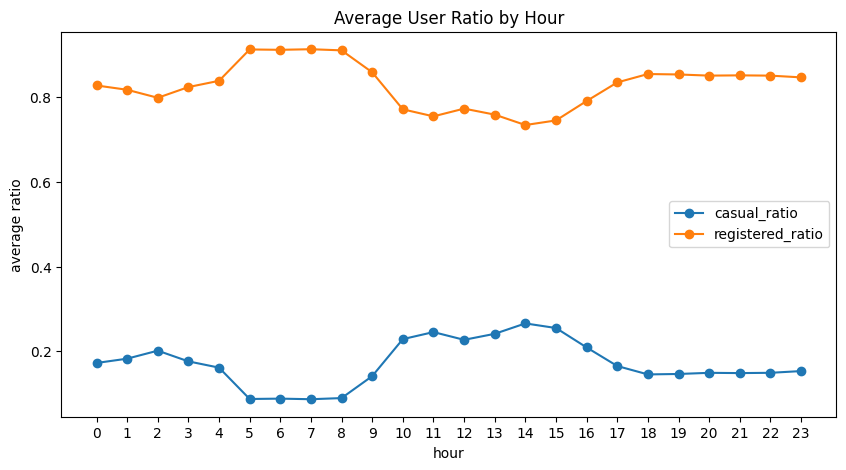

In [ ]:
df['casual_ratio'] = df['casual'] / df['count']
df['registered_ratio'] = df['registered'] / df['count']
df[['casual_ratio', 'registered_ratio']].describe()
ratio_hour = df.groupby('hour')[['casual_ratio', 'registered_ratio']].mean()
ratio_hour
plt.figure(figsize=(10, 5))
plt.plot(ratio_hour.index, ratio_hour['casual_ratio'], marker='o', label='casual_ratio')
plt.plot(ratio_hour.index, ratio_hour['registered_ratio'], marker='o', label='registered_ratio')
plt.title('Average User Ratio by Hour')
plt.xlabel('hour')
plt.ylabel('average ratio')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

- 시간대에 따라 이용자 유형의 비중이 달라진다.

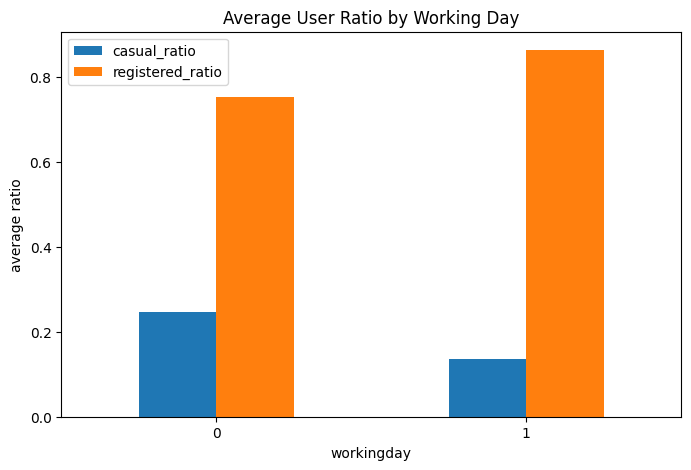

In [ ]:
ratio_workingday = df.groupby('workingday')[['casual_ratio', 'registered_ratio']].mean()
ratio_workingday
ratio_workingday.plot(kind='bar', figsize=(8, 5))
plt.title('Average User Ratio by Working Day')
plt.xlabel('workingday')
plt.ylabel('average ratio')
plt.xticks(rotation=0)
plt.show()

- 근무일에는 회원 비중이, 비근무일에는 비회원 비중이 상대적으로 커질 가능성이 있다.


## 3-23. 상관관계 확인

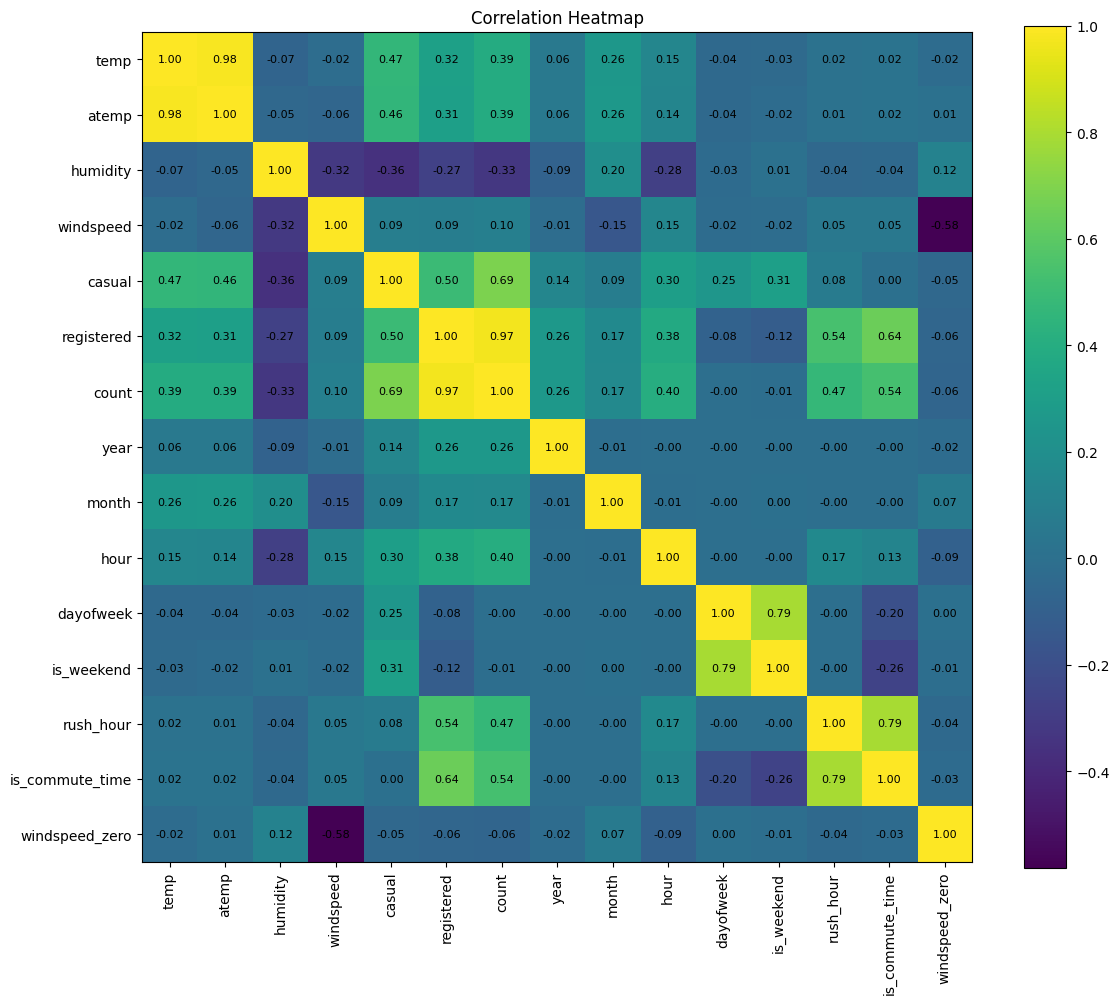

,count
count,1.000000
registered,0.970904
casual,0.690077
is_commute_time,0.536068
rush_hour,0.474031
hour,0.401366
temp,0.393893
atemp,0.389269
year,0.259054
month,0.165311


In [ ]:
corr_cols = [
    'temp', 'atemp', 'humidity', 'windspeed',
    'casual', 'registered', 'count',
    'year', 'month', 'hour', 'dayofweek',
    'is_weekend', 'rush_hour', 'is_commute_time',
    'windspeed_zero'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=8
        )

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr['count'].sort_values(ascending=False)

- count와 가장 높은 상관은 registered/casual이지만 이 둘은 target 구성요소라 모델 입력에서는 제외해야 한다.

## 3-24. (모델링에 쓸 변수 후보만) 상관관계 확인

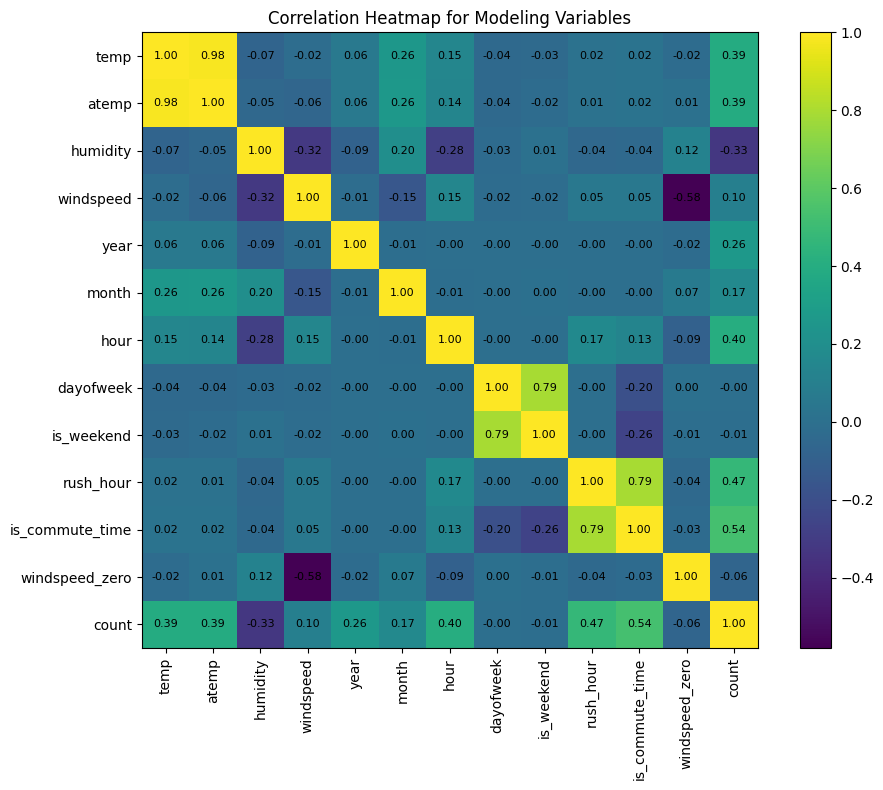

,count
count,1.000000
is_commute_time,0.536068
rush_hour,0.474031
hour,0.401366
temp,0.393893
atemp,0.389269
year,0.259054
month,0.165311
windspeed,0.102502
dayofweek,-0.002298


In [ ]:
model_corr_cols = [
    'temp', 'atemp', 'humidity', 'windspeed',
    'year', 'month', 'hour', 'dayofweek',
    'is_weekend', 'rush_hour', 'is_commute_time',
    'windspeed_zero',
    'count'
]

model_corr = df[model_corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(model_corr)
plt.colorbar()

plt.xticks(range(len(model_corr.columns)), model_corr.columns, rotation=90)
plt.yticks(range(len(model_corr.index)), model_corr.index)

for i in range(len(model_corr.index)):
    for j in range(len(model_corr.columns)):
        plt.text(
            j, i,
            f"{model_corr.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=8
        )

plt.title('Correlation Heatmap for Modeling Variables')
plt.tight_layout()
plt.show()

model_corr['count'].sort_values(ascending=False)

- count와는 is_commute_time, rush_hour, hour, temp, atemp가 상대적으로 관련성이 높다.

# 4\. 모델링

EDA 결과를 바탕으로 자전거 대여 수요에 영향을 줄 수 있는 변수를 모델 입력 변수로 구성하였다.

먼저 count 분포가 오른쪽으로 치우쳐 있어 target에 log1p 변환을 적용하였다. 또한 시간대별 대여량 차이가 크게 나타났기 때문에 hour, time_period, rush_hour, is_commute_time과 같은 시간 관련 파생변수를 사용하였다.

근무일과 주말의 이용 패턴 차이를 반영하기 위해 workingday, is_weekend를 사용하였고, 기온과 날씨에 따른 수요 차이를 반영하기 위해 temp, temp_bin, weather 변수를 활용하였다. 마지막으로 풍속 0값이 일정 규모로 존재했기 때문에 windspeed_zero 변수를 추가하여 모델이 해당 패턴을 학습할 수 있도록 하였다.

## 4-1. 모델링용 데이터 준비

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
import numpy as np

In [ ]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

- RMSLE 평가 함수를 정의한다. 예측값이 음수가 되면 0으로 보정한 뒤 RMSLE를 계산한다.

In [ ]:
drop_cols = [
    'datetime',
    'count',
    'casual',
    'registered',
    'casual_ratio',
    'registered_ratio',
    'day'
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df['count']

print(X.shape)
print(y.shape)

(10864, 20)
(10864,)


- 모델 입력에서 제외할 컬럼을 제거하고 X/y를 분리한다.
- casual/registered는 count를 직접 구성하는 변수라 사용하면 데이터 누수가 발생하므로 제외한다.

## 4-2. 범주형 변수 원-핫 인코딩

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=False)

X_encoded.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,...,time_period_evening,time_period_morning,temp_bin_cold,temp_bin_mild,temp_bin_warm,temp_bin_hot,humidity_bin_low,humidity_bin_middle,humidity_bin_high,humidity_bin_very_high
0,1,0,0,1,9.84,14.395,81,0.0,2011,1,...,False,False,True,False,False,False,False,False,False,True
1,1,0,0,1,9.02,13.635,80,0.0,2011,1,...,False,False,True,False,False,False,False,False,True,False
2,1,0,0,1,9.02,13.635,80,0.0,2011,1,...,False,False,True,False,False,False,False,False,True,False
3,1,0,0,1,9.84,14.395,75,0.0,2011,1,...,False,False,True,False,False,False,False,False,True,False
4,1,0,0,1,9.84,14.395,75,0.0,2011,1,...,False,False,True,False,False,False,False,False,True,False


- 모델이 범주형 값을 수치 입력으로 사용할 수 있게 원-핫 인코딩을 한다.

In [ ]:
X_encoded.shape

(10864, 32)

- 원-핫 인코딩으로 컬럼 수가 32개로 늘어났다.

## 4-3. Train / Validation 데이터 분리

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(7604, 32)
(3260, 32)
(7604,)
(3260,)


- 학습 데이터와 검증 데이터를 7:3 비율로 분리한다.

## 4-4 Baseline 모델: Linear Regression

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_valid)

baseline_rmsle = rmsle(y_valid, y_pred)

print("Baseline Linear Regression RMSLE:", baseline_rmsle)

Baseline Linear Regression RMSLE: 1.1253145565869784


- 기본 Linear Regression 모델을 학습하고 RMSLE를 계산한다.
- baseline RMSLE가 약 1.125로 성능이 낮은 편이다.

## 4-5. log1p 변환 적용한 Linear Regression

In [ ]:
lr_log = LinearRegression()

lr_log.fit(X_train, np.log1p(y_train))

y_pred_log = lr_log.predict(X_valid)
y_pred_log = np.expm1(y_pred_log)

log_rmsle = rmsle(y_valid, y_pred_log)

print("Linear Regression with log1p target RMSLE:", log_rmsle)

Linear Regression with log1p target RMSLE: 0.6761319949914322


- target에 log1p 변환을 적용해 Linear Regression을 학습한다.
- RMSLE가 약 0.676으로 크게 개선되어 로그 변환이 효과적이다.

## 4-6. 여러 회귀 모델 성능 비교

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

- 선형모델, 트리, 앙상블 모델을 함께 비교할 것이다.

In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        random_state=42
    )
}

model_results = []

for name, model in models.items():
    model.fit(X_train, np.log1p(y_train))

    pred_log = model.predict(X_valid)
    pred = np.expm1(pred_log)

    score = rmsle(y_valid, pred)

    model_results.append({
        'model': name,
        'rmsle': score
    })

model_result_df = pd.DataFrame(model_results).sort_values('rmsle')

model_result_df

,model,rmsle
4,RandomForest,0.326923
5,GradientBoosting,0.387414
3,DecisionTree,0.441213
2,Lasso,0.675487
1,Ridge,0.676058
0,LinearRegression,0.676132


- 여러 모델을 같은 조건으로 학습하고 RMSLE를 비교한다.
- RandomForest가 약 0.327로 가장 좋은 성능을 보인다.

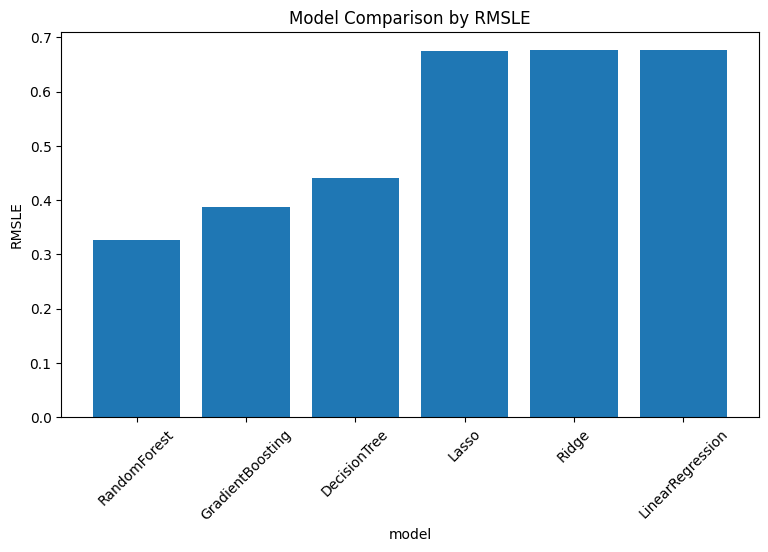

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(model_result_df['model'], model_result_df['rmsle'])
plt.title('Model Comparison by RMSLE')
plt.xlabel('model')
plt.ylabel('RMSLE')
plt.xticks(rotation=45)
plt.show()

## 4-7. RandomForest 하이퍼파라미터 튜닝

In [ ]:
rf_tuning_results = []

for n_estimators in [100, 200, 300]:
    for max_depth in [10, 20, 30, None]:
        for min_samples_split in [2, 5, 10]:
            for min_samples_leaf in [1, 2, 4]:

                rf = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42,
                    n_jobs=-1
                )

                rf.fit(X_train, np.log1p(y_train))

                pred_log = rf.predict(X_valid)
                pred = np.expm1(pred_log)

                score = rmsle(y_valid, pred)

                rf_tuning_results.append({
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf,
                    'rmsle': score
                })

rf_tuning_df = pd.DataFrame(rf_tuning_results).sort_values('rmsle')

rf_tuning_df.head(10)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,rmsle
99,300,NaN,2,1,0.326441
90,300,30.0,2,1,0.326576
81,300,20.0,2,1,0.326765
63,200,NaN,2,1,0.326923
54,200,30.0,2,1,0.327072
45,200,20.0,2,1,0.327096
102,300,NaN,5,1,0.327339
93,300,30.0,5,1,0.327360
84,300,20.0,5,1,0.327403
48,200,20.0,5,1,0.327532


- RandomForest의 주요 하이퍼파라미터 조합을 반복 탐색한다. 가장 (낮은 RMSLE를 내는 조합 찾기)

## 4-8. 최적 파라미터 확인

In [ ]:
best_params = rf_tuning_df.iloc[0]

best_params

,99
n_estimators,300.000000
max_depth,NaN
min_samples_split,2.000000
min_samples_leaf,1.000000
rmsle,0.326441


- 최적 조합은 n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1이다.

## 4-9. 최종 RandomForest 모델 학습

In [ ]:
final_rf = RandomForestRegressor(
    n_estimators=int(best_params['n_estimators']),
    max_depth=None if pd.isna(best_params['max_depth']) else int(best_params['max_depth']),
    min_samples_split=int(best_params['min_samples_split']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, np.log1p(y_train))

final_pred_log = final_rf.predict(X_valid)
final_pred = np.expm1(final_pred_log)

final_rmsle = rmsle(y_valid, final_pred)

print("Final RandomForest RMSLE:", final_rmsle)

Final RandomForest RMSLE: 0.32644149320589577


- 최적 파라미터로 최종 RandomForest 모델을 학습한다.
- 최종 RMSLE는 약 0.3264로 기준 0.4 이하를 충족한다.

## 4-10. 튜닝 전후 성능 비교

In [ ]:
rf_rmsle = model_result_df[model_result_df['model'] == 'RandomForest']['rmsle'].values[0]

- 튜닝 전 RandomForest RMSLE 값을 가져온다.

In [ ]:
performance_compare = pd.DataFrame({
    'model': ['Baseline LinearRegression', 'Log LinearRegression', 'RandomForest', 'Tuned RandomForest'],
    'rmsle': [baseline_rmsle, log_rmsle, rf_rmsle, final_rmsle]
})

performance_compare

,model,rmsle
0,Baseline LinearRegression,1.125315
1,Log LinearRegression,0.676132
2,RandomForest,0.326923
3,Tuned RandomForest,0.326441


- 튜닝 후의 RandomForest가 가장 낮은 RMSLE이다!

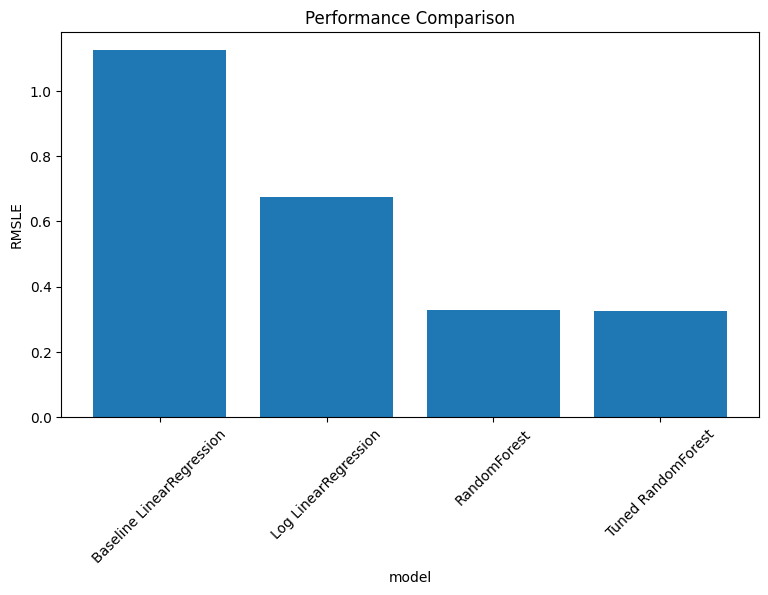

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(performance_compare['model'], performance_compare['rmsle'])
plt.title('Performance Comparison')
plt.xlabel('model')
plt.ylabel('RMSLE')
plt.xticks(rotation=45)
plt.show()

# 5\. 최종 모델 성능 평가

## 5-1. 변수 중요도 확인

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': final_rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
10,hour,0.541241
21,time_period_dawn,0.174425
4,temp,0.044131
14,is_commute_time,0.039428
2,workingday,0.033188
8,year,0.026671
5,atemp,0.025299
9,month,0.024840
6,humidity,0.023402
11,dayofweek,0.015538


- hour, time_period_dawn, temp, is_commute_time 등이 주요 변수로 나타난다.

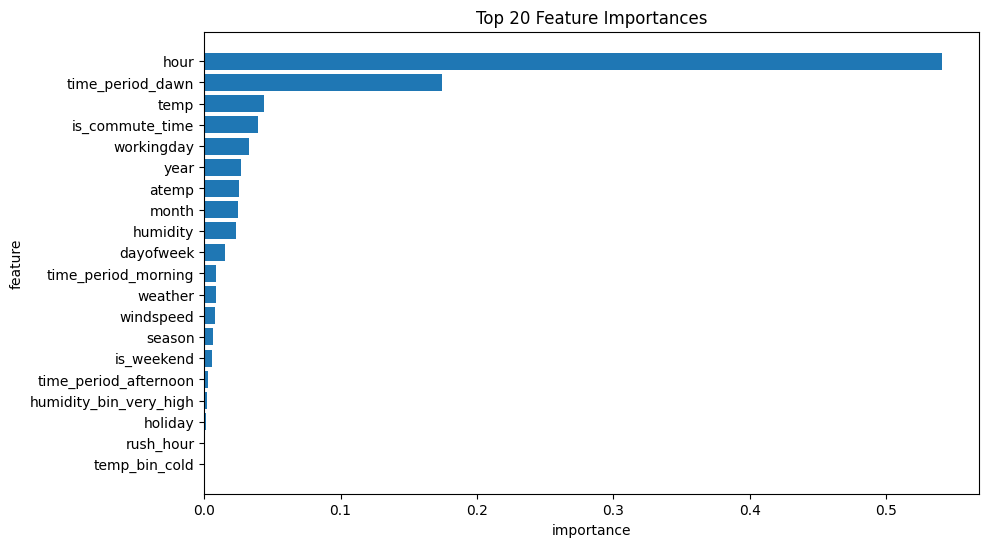

In [ ]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 20 Feature Importances')
plt.xlabel('importance')
plt.ylabel('feature')
plt.gca().invert_yaxis()
plt.show()

- 시간 관련 변수가 자전거 수요 예측에서 가장 큰 영향력을 보인다.

## 5-2. 실제값 vs 예측값 확인

In [ ]:
pred_compare = pd.DataFrame({
    'actual': y_valid,
    'predicted': final_pred
})

pred_compare.head(20)

,actual,predicted
2678,170,152.567762
7580,6,4.486073
8201,159,127.034495
2122,104,107.205882
9188,9,7.198636
5312,459,392.415497
9403,89,71.667394
6883,38,23.627865
1147,122,133.823115
1010,39,13.546721


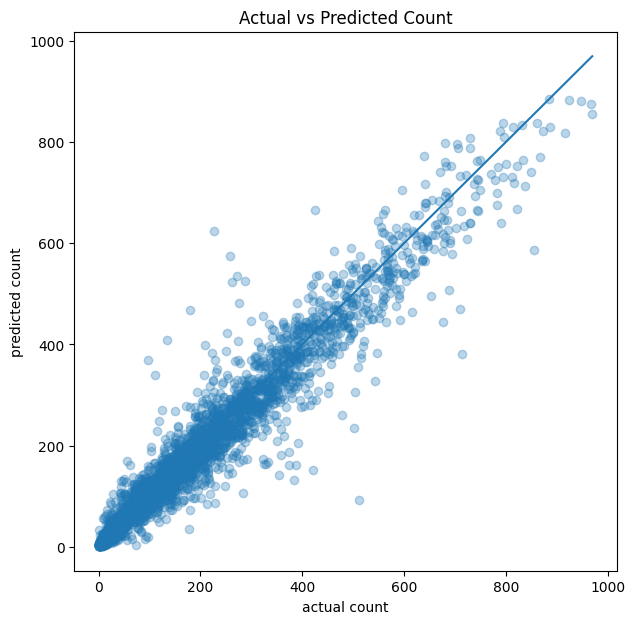

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(pred_compare['actual'], pred_compare['predicted'], alpha=0.3)
plt.plot(
    [pred_compare['actual'].min(), pred_compare['actual'].max()],
    [pred_compare['actual'].min(), pred_compare['actual'].max()]
)
plt.title('Actual vs Predicted Count')
plt.xlabel('actual count')
plt.ylabel('predicted count')
plt.show()

- 전반적으로 큰 흐름은 따라가고 있다!

## 5-3. 예측 오차 확인

In [ ]:
pred_compare['error'] = pred_compare['actual'] - pred_compare['predicted']
pred_compare['abs_error'] = abs(pred_compare['error'])

pred_compare.head()

,actual,predicted,error,abs_error
2678,170,152.567762,17.432238,17.432238
7580,6,4.486073,1.513927,1.513927
8201,159,127.034495,31.965505,31.965505
2122,104,107.205882,-3.205882,3.205882
9188,9,7.198636,1.801364,1.801364


- 일부 데이터에서는 실제값과 예측값의 차이가 작게 나타났지만, 특정 데이터에서는 차이가 비교적 크게 나타났다.
- 이를 통해 모델이 전체적인 패턴은 학습했지만, 일부 수요가 급격히 많거나 적은 상황에서는 예측 오차가 발생할 수 있음을 확인하였다.

In [ ]:
pred_compare[['actual', 'predicted', 'error', 'abs_error']].describe()

,actual,predicted,error,abs_error
count,3260.000000,3260.000000,3260.000000,3260.000000
mean,191.966871,187.996444,3.970428,26.702261
std,180.077184,173.812972,44.055068,35.261716
min,1.000000,1.399866,-396.578882,0.012243
25%,44.000000,46.957406,-12.699425,5.139174
50%,147.000000,145.294189,0.444590,15.004982
75%,282.000000,277.647235,17.980623,35.587855
max,970.000000,884.758309,419.829645,419.829645


- 평균 절대오차는 약 26.7건이며, 일부 큰 오차 사례가 존재한다.

## 5-4. 오차 분포 시각화

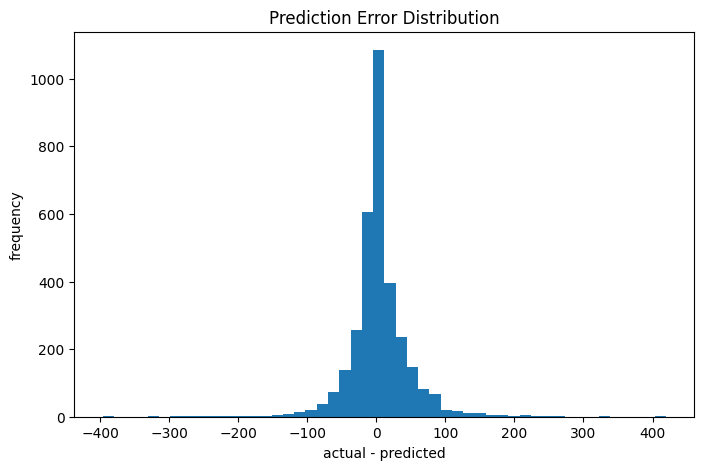

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(pred_compare['error'], bins=50)
plt.title('Prediction Error Distribution')
plt.xlabel('actual - predicted')
plt.ylabel('frequency')
plt.show()

- 대부분의 오차는 0 근처에 몰려 있지만 일부 큰 오차가 있다.

## 5-5. 실제값 대비 오차 확인

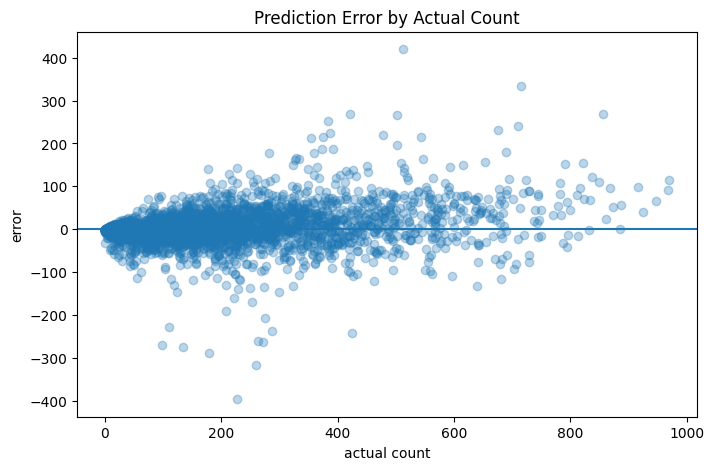

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pred_compare['actual'], pred_compare['error'], alpha=0.3)
plt.axhline(0)
plt.title('Prediction Error by Actual Count')
plt.xlabel('actual count')
plt.ylabel('error')
plt.show()

- 실제 대여 수가 적은 구간에서는 오차가 비교적 좁게 분포하지만 실제 대여 수가 증가할수록 오차의 범위가 넓어지는 경향이 나타난다.
- 이는 대여 수가 많은 상황일수록 모델의 예측이 더 어려워질 수 있음을 의미한다.
- 또한 오차가 0을 기준으로 위아래에 모두 분포하고 있어, 모델이 특정 방향으로만 과대예측하거나 과소예측한다고 보기는 어렵다.

## 5-6. 오차가 큰 데이터 확인

In [ ]:
error_check = pred_compare.sort_values('abs_error', ascending=False)

error_check.head(20)

,actual,predicted,error,abs_error
9224,512,92.170355,419.829645,419.829645
7690,227,623.578882,-396.578882,396.578882
9538,715,381.583213,333.416787,333.416787
2013,259,575.853088,-316.853088,316.853088
8904,179,467.359598,-288.359598,288.359598
9529,134,409.065273,-275.065273,275.065273
7428,98,368.373866,-270.373866,270.373866
9514,856,586.461112,269.538888,269.538888
3424,421,151.867935,269.132065,269.132065
8223,502,235.551754,266.448246,266.448246


- 오차가 큰 데이터에서는 실제 대여 수와 예측 대여 수의 차이가 크게 나타났다.
  - 예를 들어 실제 대여 수가 512대였지만 모델은 약 92대로 예측한 경우처럼, 실제 수요를 크게 낮게 예측한 사례가 있었다.
  - 반대로 실제 대여 수보다 훨씬 높게 예측한 사례도 확인되었다.

- 이는 자전거 대여 수요가 단순히 시간, 날씨, 근무일 여부만으로 완벽하게 설명되기 어렵다는 점을 보여준다.
- 특정 이벤트, 지역적 요인, 갑작스러운 날씨 변화, 데이터에 포함되지 않은 외부 요인 등이 예측 오차에 영향을 주었을 가능성이 있다.

In [ ]:
error_detail = X_valid.copy()
error_detail['actual'] = y_valid
error_detail['predicted'] = final_pred
error_detail['error'] = error_detail['actual'] - error_detail['predicted']
error_detail['abs_error'] = abs(error_detail['error'])

error_detail.sort_values('abs_error', ascending=False).head(20)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,...,temp_bin_warm,temp_bin_hot,humidity_bin_low,humidity_bin_middle,humidity_bin_high,humidity_bin_very_high,actual,predicted,error,abs_error
9224,3,0,0,3,22.96,26.515,88,16.9979,2012,9,...,True,False,False,False,False,True,512,92.170355,419.829645,419.829645
7690,2,0,1,3,28.70,32.575,70,16.9979,2012,6,...,True,False,False,False,True,False,227,623.578882,-396.578882,396.578882
9538,4,0,1,3,25.42,28.030,88,7.0015,2012,10,...,True,False,False,False,False,True,715,381.583213,333.416787,333.416787
2013,2,0,1,1,26.24,31.060,47,7.0015,2011,5,...,True,False,False,True,False,False,259,575.853088,-316.853088,316.853088
8904,3,0,1,2,27.06,30.305,83,6.0032,2012,8,...,True,False,False,False,False,True,179,467.359598,-288.359598,288.359598
9529,4,0,1,3,24.60,27.275,88,0.0000,2012,10,...,True,False,False,False,False,True,134,409.065273,-275.065273,275.065273
7428,2,0,1,3,20.50,24.240,77,23.9994,2012,5,...,True,False,False,False,True,False,98,368.373866,-270.373866,270.373866
9514,4,0,1,3,22.96,26.515,60,16.9979,2012,10,...,True,False,False,True,False,False,856,586.461112,269.538888,269.538888
3424,3,0,0,2,27.06,29.545,89,11.0014,2011,8,...,True,False,False,False,False,True,421,151.867935,269.132065,269.132065
8223,3,1,0,1,33.62,39.395,56,15.0013,2012,7,...,False,True,False,True,False,False,502,235.551754,266.448246,266.448246


## 5-7. 최종 결과 요약

In [ ]:
final_summary = pd.DataFrame({
    'item': [
        '최종 모델',
        '최종 RMSLE',
        '기준 RMSLE',
        '기준 충족 여부',
        '주요 중요 변수'
    ],
    'result': [
        'Tuned RandomForest',
        round(final_rmsle, 4),
        '0.4 이하',
        '충족',
        ', '.join(feature_importance.head(5)['feature'].tolist())
    ]
})

final_summary

,item,result
0,최종 모델,Tuned RandomForest
1,최종 RMSLE,0.3264
2,기준 RMSLE,0.4 이하
3,기준 충족 여부,충족
4,주요 중요 변수,"hour, time_period_dawn, temp, is_commute_time,..."


- 최종 모델은 하이퍼파라미터 튜닝을 적용한 RandomForest 모델이다.

  - 최종 RMSLE는 약 0.3264로 나타났으며, 평가 기준이었던 0.4 이하를 충족하였다.
  - 주요 중요 변수는 hour, time_period_dawn, temp, is_commute_time, workingday 등으로 나타났다.
  - 이는 자전거 대여 수요 예측에서 시간대, 새벽 여부, 기온, 출퇴근 시간 여부, 근무일 여부가 중요한 영향을 미친다는 것을 의미한다.

# 6\. 최종 결론

- 이번 분석에서는 미국 워싱턴 D.C. 지역의 자전거 대여 데이터를 활용하여 대여 패턴을 탐색하고, 자전거 대여 수요를 예측하는 머신러닝 모델을 구축하였다.

- EDA 결과, 자전거 대여 수요는 시간대에 따라 큰 차이를 보였으며, 특히 출퇴근 시간대와 근무일 여부에 따라 이용 패턴이 달라지는 것을 확인하였다. 또한 기온이 높아질수록 대여량이 증가하는 경향이 있었고, 날씨가 좋지 않거나 습도가 높은 경우에는 대여량이 감소하는 경향이 나타났다.

- 모델링 과정에서는 기본 선형회귀 모델을 먼저 구축한 뒤, 로그 변환을 적용한 선형회귀 모델, 여러 회귀 모델 비교, RandomForest 하이퍼파라미터 튜닝을 순서대로 진행하였다. 기본 선형회귀 모델의 RMSLE는 약 1.1253으로 높게 나타났지만, 로그 변환과 비선형 모델을 적용하면서 성능이 크게 개선되었다.

- 최종 모델은 하이퍼파라미터 튜닝을 적용한 RandomForest 모델로 선정하였다. 최종 RMSLE는 약 0.3264로, 목표 기준이었던 0.4 이하를 충족하였다. 변수 중요도 분석 결과 hour, time_period_dawn, temp, is_commute_time, workingday 등이 주요 변수로 나타나, 자전거 대여 수요는 날씨뿐만 아니라 시간대와 이용 목적에 가까운 변수의 영향을 크게 받는 것으로 해석할 수 있다.

- 다만 실제 대여 수가 많은 구간에서는 예측 오차가 커지는 경향이 있었고, 일부 데이터에서는 실제값과 예측값의 차이가 크게 나타났다. 이는 특정 이벤트, 지역적 요인, 갑작스러운 날씨 변화 등 데이터에 포함되지 않은 외부 요인이 자전거 대여 수요에 영향을 줄 수 있음을 의미한다.

- 따라서 이번 모델은 전체적인 자전거 대여 수요 패턴을 예측하는 데에는 유용하지만, 향후 더 정교한 예측을 위해서는 이벤트 정보, 지역 정보, 세부 날씨 정보, 시간 기반 검증 방식 등을 추가로 고려할 필요가 있다.

# 7. Appendix. 보고서용 시각화

In [ ]:
main_green = '#2E7D32'
light_green = '#66BB6A'
pale_green = '#A5D6A7'
gray = '#666666'

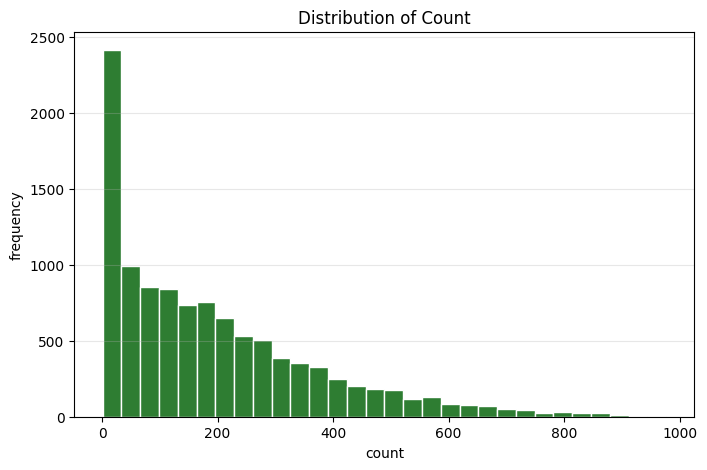

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['count'], bins=30, color=main_green, edgecolor='white')

plt.title('Distribution of Count')
plt.xlabel('count')
plt.ylabel('frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

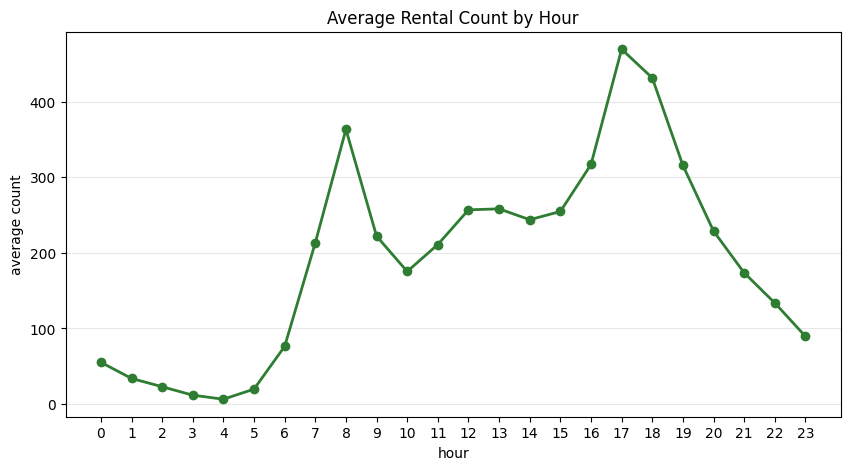

In [ ]:
hour_count = df.groupby('hour')['count'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(
    hour_count['hour'],
    hour_count['count'],
    marker='o',
    color=main_green,
    linewidth=2
)

plt.title('Average Rental Count by Hour')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)

plt.show()

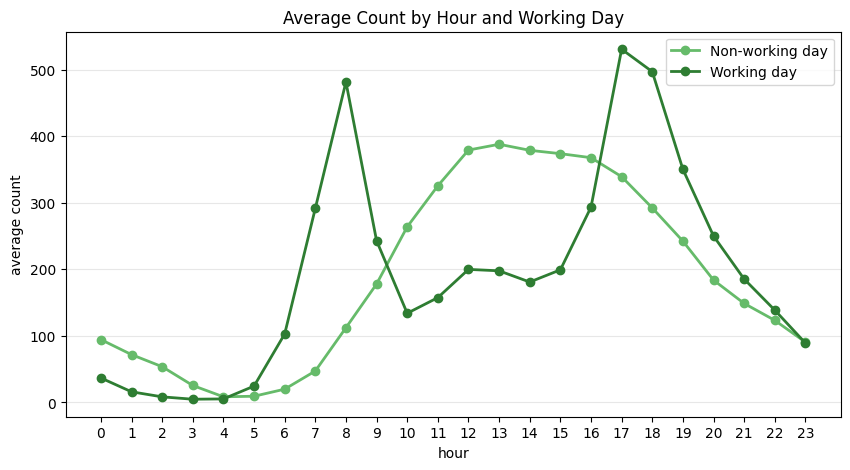

In [ ]:
working_hour = df.groupby(['hour', 'workingday'])['count'].mean().reset_index()

working_pivot = working_hour.pivot(index='hour', columns='workingday', values='count')

plt.figure(figsize=(10, 5))
plt.plot(
    working_pivot.index,
    working_pivot[0],
    marker='o',
    color=light_green,
    linewidth=2,
    label='Non-working day'
)
plt.plot(
    working_pivot.index,
    working_pivot[1],
    marker='o',
    color=main_green,
    linewidth=2,
    label='Working day'
)

plt.title('Average Count by Hour and Working Day')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

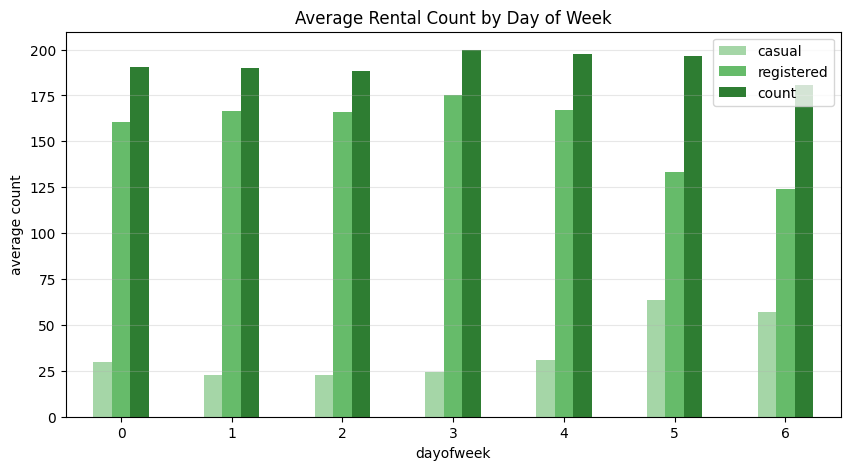

In [ ]:
dayofweek_count = df.groupby('dayofweek')[['casual', 'registered', 'count']].mean().reset_index()

dayofweek_count.plot(
    x='dayofweek',
    y=['casual', 'registered', 'count'],
    kind='bar',
    figsize=(10, 5),
    color=[pale_green, light_green, main_green]
)

plt.title('Average Rental Count by Day of Week')
plt.xlabel('dayofweek')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(['casual', 'registered', 'count'])

plt.show()

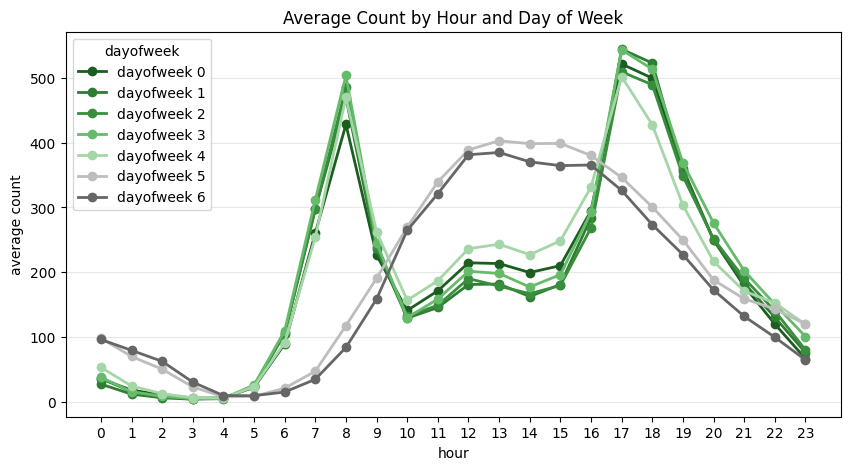

In [ ]:
hour_day_count = df.groupby(['hour', 'dayofweek'])['count'].mean().reset_index()

hour_day_pivot = hour_day_count.pivot(
    index='hour',
    columns='dayofweek',
    values='count'
)

day_colors = [
    '#1B5E20',  # 0
    main_green, # 1
    '#388E3C',  # 2
    light_green,# 3
    pale_green, # 4
    '#BDBDBD',# 5
    gray      # 6
]

plt.figure(figsize=(10, 5))

for i, day in enumerate(hour_day_pivot.columns):
    plt.plot(
        hour_day_pivot.index,
        hour_day_pivot[day],
        marker='o',
        linewidth=2,
        color=day_colors[i],
        label=f'dayofweek {day}'
    )

plt.title('Average Count by Hour and Day of Week')
plt.xlabel('hour')
plt.ylabel('average count')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='dayofweek')

plt.show()

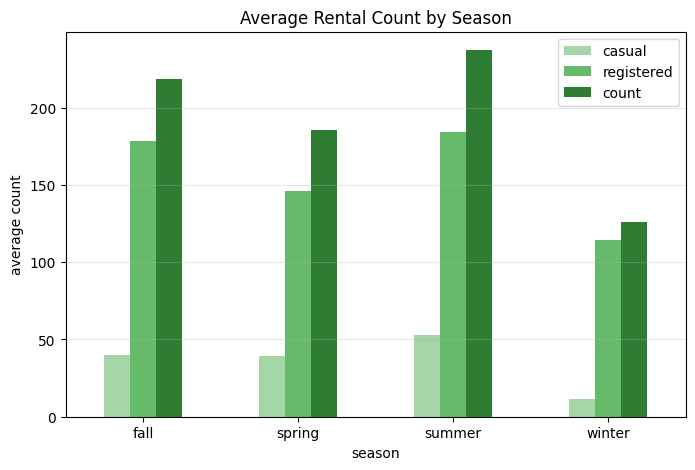

In [ ]:
season_user = df.groupby('season_month')[['casual', 'registered', 'count']].mean().reset_index()

season_user.plot(
    x='season_month',
    y=['casual', 'registered', 'count'],
    kind='bar',
    figsize=(8, 5),
    color=[pale_green, light_green, main_green]
)

plt.title('Average Rental Count by Season')
plt.xlabel('season')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(['casual', 'registered', 'count'])

plt.show()

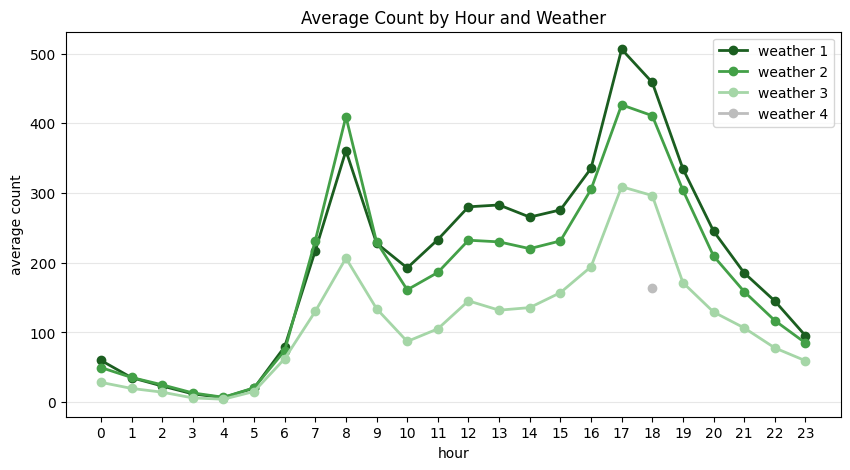

In [ ]:
weather_hour = df.groupby(['hour', 'weather'])['count'].mean().reset_index()

weather_pivot = weather_hour.pivot(index='hour', columns='weather', values='count')

weather_colors = ['#1B5E20', '#43A047', '#A5D6A7', '#BDBDBD']

plt.figure(figsize=(10, 5))

for i, weather in enumerate(weather_pivot.columns):
    plt.plot(
        weather_pivot.index,
        weather_pivot[weather],
        marker='o',
        linewidth=2,
        color=weather_colors[i],
        label=f'weather {weather}'
    )

plt.title('Average Count by Hour and Weather')
plt.xlabel('hour')
plt.ylabel('average count')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

/tmp/ipykernel_5947/480007434.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_count = df.groupby('temp_bin')[['casual', 'registered', 'count']].mean().reset_index()


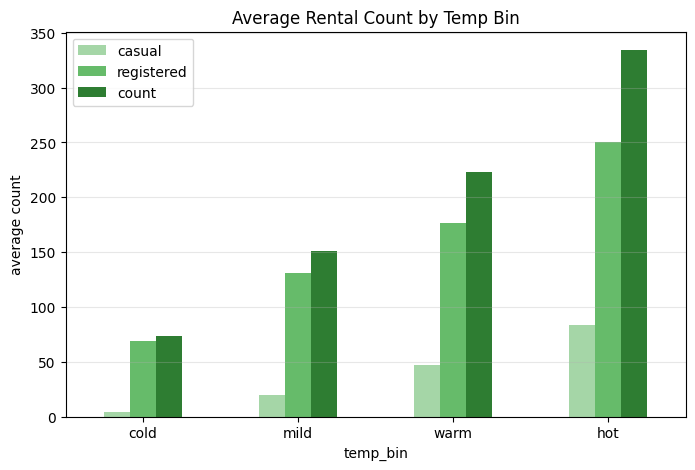

In [ ]:
temp_bin_count = df.groupby('temp_bin')[['casual', 'registered', 'count']].mean().reset_index()

temp_bin_count.plot(
    x='temp_bin',
    y=['casual', 'registered', 'count'],
    kind='bar',
    figsize=(8, 5),
    color=[pale_green, light_green, main_green]
)

plt.title('Average Rental Count by Temp Bin')
plt.xlabel('temp_bin')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(['casual', 'registered', 'count'])

plt.show()

/tmp/ipykernel_5947/2283461762.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humidity_bin_count = df.groupby('humidity_bin')[['casual', 'registered', 'count']].mean().reset_index()


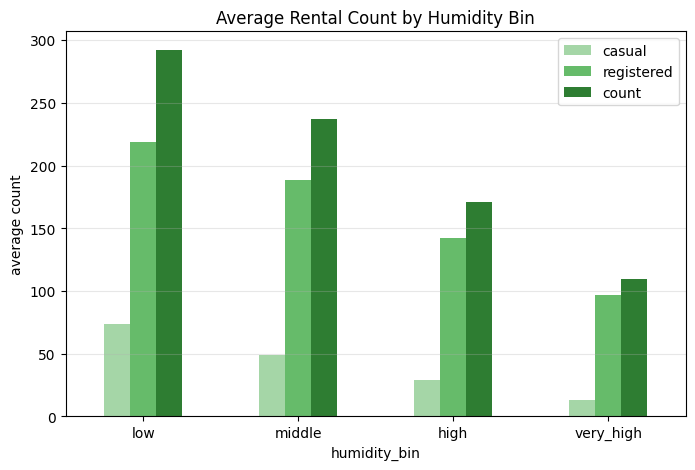

In [ ]:
humidity_bin_count = df.groupby('humidity_bin')[['casual', 'registered', 'count']].mean().reset_index()

humidity_bin_count.plot(
    x='humidity_bin',
    y=['casual', 'registered', 'count'],
    kind='bar',
    figsize=(8, 5),
    color=[pale_green, light_green, main_green]
)

plt.title('Average Rental Count by Humidity Bin')
plt.xlabel('humidity_bin')
plt.ylabel('average count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(['casual', 'registered', 'count'])

plt.show()

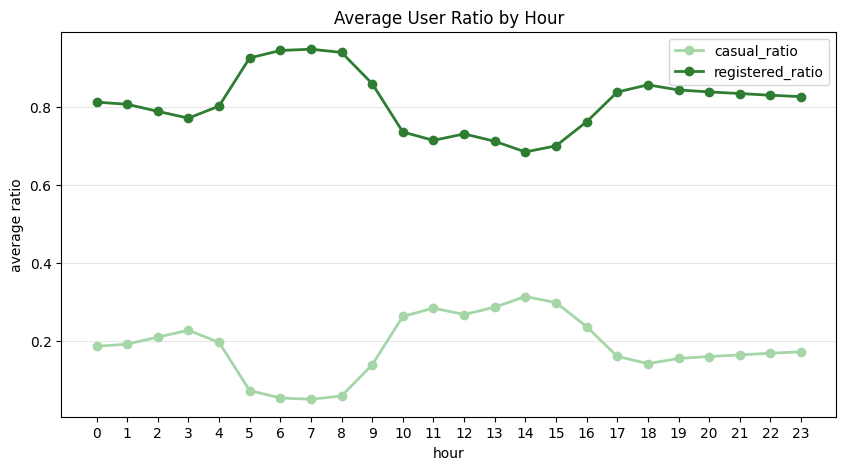

In [ ]:
user_ratio_hour = df.groupby('hour')[['casual', 'registered', 'count']].sum().reset_index()

user_ratio_hour['casual_ratio'] = user_ratio_hour['casual'] / user_ratio_hour['count']
user_ratio_hour['registered_ratio'] = user_ratio_hour['registered'] / user_ratio_hour['count']

plt.figure(figsize=(10, 5))
plt.plot(
    user_ratio_hour['hour'],
    user_ratio_hour['casual_ratio'],
    marker='o',
    color=pale_green,
    linewidth=2,
    label='casual_ratio'
)
plt.plot(
    user_ratio_hour['hour'],
    user_ratio_hour['registered_ratio'],
    marker='o',
    color=main_green,
    linewidth=2,
    label='registered_ratio'
)

plt.title('Average User Ratio by Hour')
plt.xlabel('hour')
plt.ylabel('average ratio')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

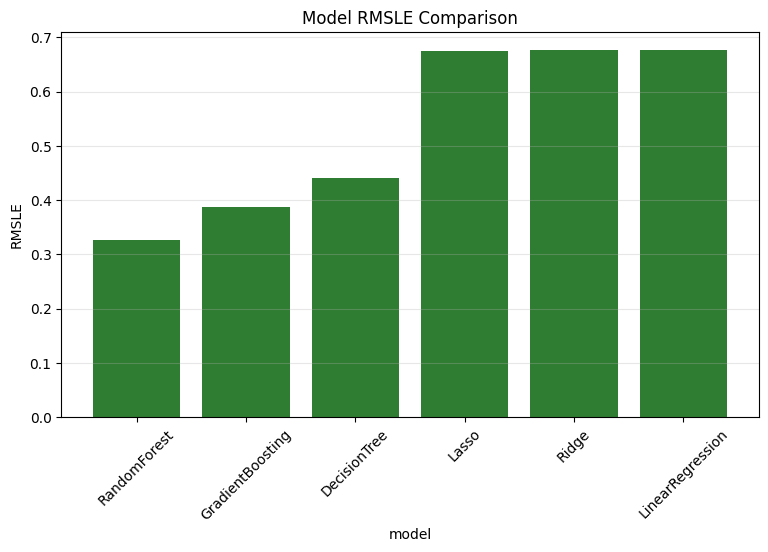

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_result_df['model'],
    model_result_df['rmsle'],
    color=main_green
)

plt.title('Model RMSLE Comparison')
plt.xlabel('model')
plt.ylabel('RMSLE')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

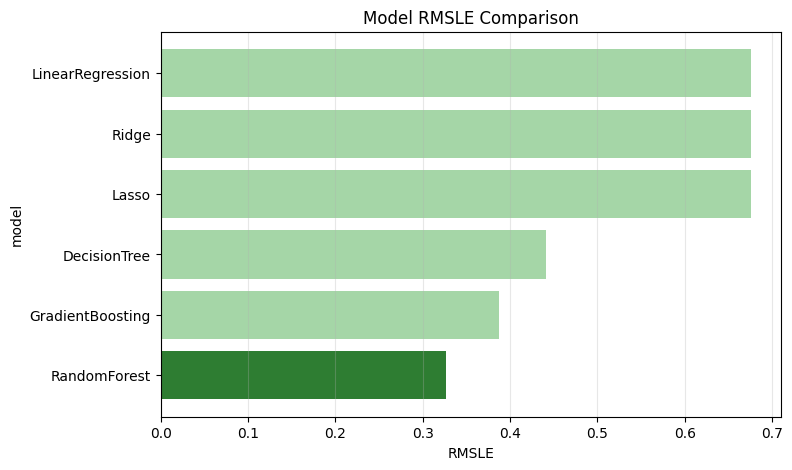

In [ ]:
model_result_sorted = model_result_df.sort_values('rmsle', ascending=True)

colors = [
    main_green if model == 'RandomForest' else pale_green
    for model in model_result_sorted['model']
]

plt.figure(figsize=(8, 5))

plt.barh(
    model_result_sorted['model'],
    model_result_sorted['rmsle'],
    color=colors
)

plt.title('Model RMSLE Comparison')
plt.xlabel('RMSLE')
plt.ylabel('model')
plt.grid(axis='x', alpha=0.3)

plt.show()

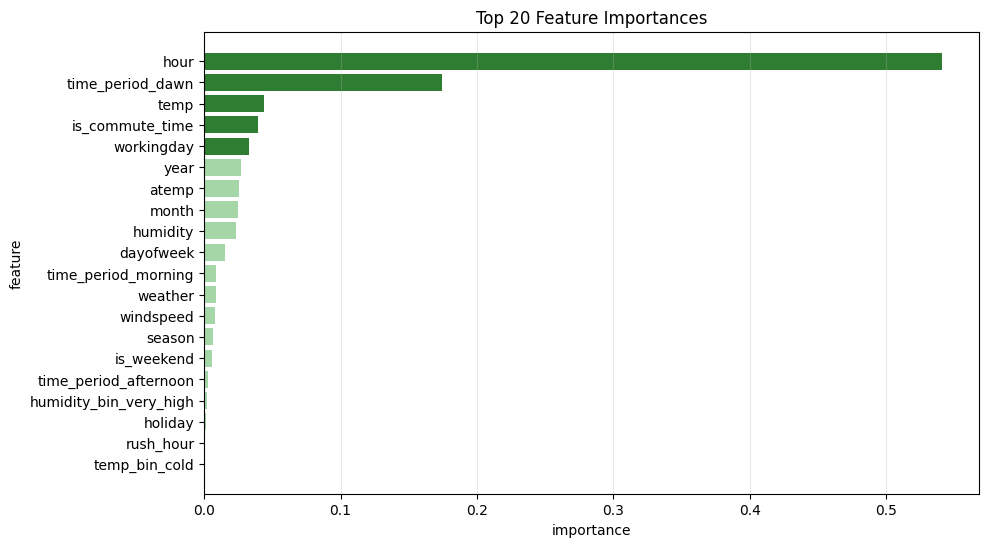

In [ ]:
top_features = feature_importance.head(20)

colors = [
    main_green if i < 5 else pale_green
    for i in range(len(top_features))
]

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['feature'],
    top_features['importance'],
    color=colors
)

plt.title('Top 20 Feature Importances')
plt.xlabel('importance')
plt.ylabel('feature')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()

plt.show()

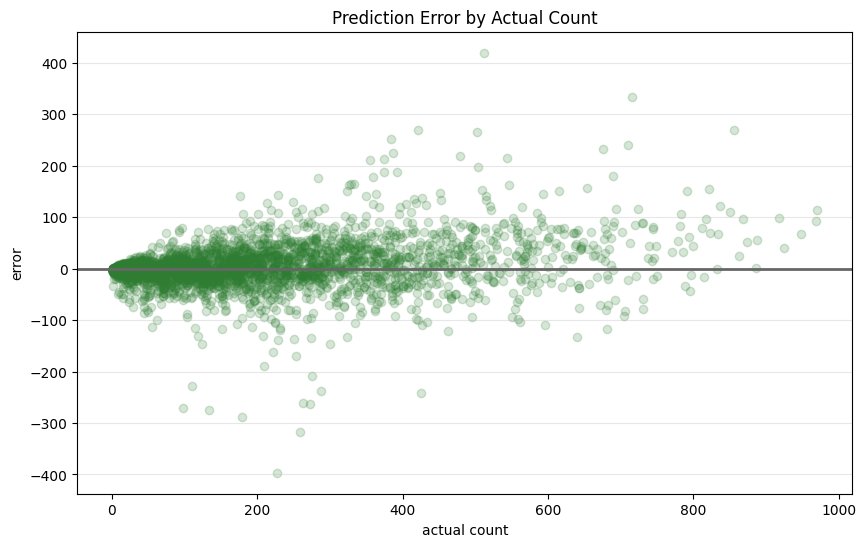

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    pred_compare['actual'],
    pred_compare['error'],
    alpha=0.2,
    color=main_green
)

plt.axhline(
    y=0,
    color=gray,
    linewidth=2
)

plt.title('Prediction Error by Actual Count')
plt.xlabel('actual count')
plt.ylabel('error')
plt.grid(axis='y', alpha=0.3)

plt.show()